# ST-GNN_Pilot2

Черновой ноутбук для ST-GNN анализа NaPi2b на основе `MANIA_preprocessing_v1.1` и `MANIA_analysis_v1.1`.

Цели ноутбука:
- загрузить артефакты MANIA;
- собрать `HeteroData`-графы по кадрам и временным окнам;
- обучить обновлённый `ConformationAutoencoder_v3`;
- обучить корректный `SpatioTemporalGNN`;
- сравнить ST-GNN с baseline-моделями;
- проверить устойчивость результата и связать выводы с MANIA-метриками.

Важно: это **рабочий шаблон**, а не финальная production-версия. Перед окончательным запуском нужно проверить пути, названия колонок и формат exported CSV/Parquet.

## Раздел 0. Установка и конфиг

Здесь фиксируются зависимости, параметры эксперимента и пути. Смысл этого блока — сделать ноутбук воспроизводимым и не размазывать гиперпараметры по всем ячейкам.

In [ ]:
# Опционально: установка пакетов в Colab
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install -q pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.4.0+cpu.html
!pip install -q pandas numpy pyarrow scikit-learn xgboost umap-learn hdbscan matplotlib seaborn tqdm yadisk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.9/542.9 kB 41.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 792.6/792.6 kB 52.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.5/237.5 kB 321.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.7/140.7 kB 11.6 MB/s eta 0:00:00


In [ ]:
import os
import json
import math
import pickle
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv, global_mean_pool

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

import xgboost as xgb
import umap
import hdbscan

import matplotlib.pyplot as plt
import seaborn as sns

import yadisk

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Torch:', torch.__version__)

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/libpyg.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cpu.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_sparse/_version_cpu.so
  import torch_geometric.typing


Device: cuda
Torch: 2.11.0+cu128


In [ ]:
CONFIG = {
    'conditions': ['normal', 'tumor'],
    'condition_to_label': {'normal': 0, 'tumor': 1},

    # Данные
    'n_frames_parquet': 301,
    'traj_window': 5,
    'traj_stride': 1,

    # Узлы
    'node_types': ['protein', 'lipid', 'glycan'],
    'protein_feat_dim': 38,
    'lipid_feat_dim': None,
    'glycan_feat_dim': None,

    # Рёбра
    'edge_types': [
        'backbone', 'hbond', 'disulfide', 'vdw', 'hydrophobic',
        'aromaticpi', 'cationpi', 'ionic', 'saltbridge',
        'proteinlipid', 'glycananchor', 'proteinglycan', 'proteinligand'
    ],

    # Модели
    'frame_hidden_dim': 128,
    'latent_dim': 128,
    'gru_hidden_dim': 128,
    'gru_layers': 2,
    'dropout': 0.3,

    # Обучение
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'max_epochs': 100,
    'patience': 15,
    'batch_size': 1,

    # UMAP / HDBSCAN
    'umap_neighbors': 15,
    'umap_min_dist': 0.1,
    'hdbscan_min_cluster_sizes': [5, 7, 10, 15],

    # Sensitivity analysis
    'window_sensitivity': [3, 5, 7],

    # Seed
    'seed': 42,
}

np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])

MANIA_DIR = Path('./maniaoutput')
OUTPUT_DIR = Path('./output_stgnn_pilot2')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
PKL_PATH = OUTPUT_DIR / 'hetero_graphs_pilot2.pkl'

print('MANIA_DIR =', MANIA_DIR)
print('OUTPUT_DIR =', OUTPUT_DIR)
print('PKL_PATH =', PKL_PATH)

MANIA_DIR = maniaoutput
OUTPUT_DIR = output_stgnn_pilot2
PKL_PATH = output_stgnn_pilot2/hetero_graphs_pilot2.pkl


## Раздел 0b. Источник артефактов и загрузка с YaDisk

Этот блок добавляет инфраструктурную загрузку артефактов MANIA из YaDisk.
Ключевые моменты:
- используется переменная окружения `MW_TOKEN`;
- имена файлов в snake_case;
- файлы могут лежать в разных папках и подпапках (используем рекурсивную загрузку и поиск).

In [ ]:
# Источник артефактов: 'local' или 'yadisk'
SOURCE_ARTEFACTS = 'yadisk'

# Токен YaDisk — важно: именно MW_TOKEN (snake_case)
MW_TOKEN = os.environ.get('MW_TOKEN', None)

# Корневая папка preprocess export на YaDisk
YADISK_PREPROCESS_ROOT = 'disk:/MANIA_WANIA_project/MD_trajectories/NaPi2b/Ramilia/100ns/phase3aexports'

# При необходимости можно отдельно указать analysis export (здесь совпадает с preprocess)
YADISK_ANALYSIS_ROOT = 'disk:/MANIA_WANIA_project/MD_trajectories/NaPi2b/Ramilia/100ns/phase3bexports'

# Локальные директории
MANIA_PREPROCESS_DIR = MANIA_DIR              # сюда тянем preprocess
MANIA_ANALYSIS_DIR = MANIA_DIR               # analysis CSV (centrality, stats и т.п.) пока туда же
MANIA_FIGURES_DIR = MANIA_DIR / 'figures'    # фигуры в отдельной подпапке

MANIA_PREPROCESS_DIR.mkdir(exist_ok=True, parents=True)
MANIA_ANALYSIS_DIR.mkdir(exist_ok=True, parents=True)
MANIA_FIGURES_DIR.mkdir(exist_ok=True, parents=True)

print('SOURCE_ARTEFACTS =', SOURCE_ARTEFACTS)
print('MW_TOKEN is set =', MW_TOKEN is not None)
print('YADISK_PREPROCESS_ROOT =', YADISK_PREPROCESS_ROOT)
print('YADISK_ANALYSIS_ROOT =', YADISK_ANALYSIS_ROOT)
print('MANIA_PREPROCESS_DIR =', MANIA_PREPROCESS_DIR)
print('MANIA_ANALYSIS_DIR =', MANIA_ANALYSIS_DIR)
print('MANIA_FIGURES_DIR =', MANIA_FIGURES_DIR)

SOURCE_ARTEFACTS = yadisk
MW_TOKEN is set = False
YADISK_PREPROCESS_ROOT = disk:/MANIA_WANIA_project/MD_trajectories/NaPi2b/Ramilia/100ns/phase3aexports
YADISK_ANALYSIS_ROOT = disk:/MANIA_WANIA_project/MD_trajectories/NaPi2b/Ramilia/100ns/phase3bexports
MANIA_PREPROCESS_DIR = maniaoutput
MANIA_ANALYSIS_DIR = maniaoutput
MANIA_FIGURES_DIR = maniaoutput/figures


In [ ]:
import time

def resolve_ya_disk_token():
    if MW_TOKEN:
        return MW_TOKEN
    try:
        from google.colab import userdata
        token = userdata.get('MW_TOKEN')
        if token:
            return token
    except Exception:
        pass
    raise ValueError(
        'YaDisk token not found. '
        'Set MW_TOKEN in environment or via Colab Secrets.'
    )

def ya_disk_download_file(client, remote_path: str, local_path: Path):
    if local_path.exists():
        print(f'[cache] {local_path}')
        return
    local_path.parent.mkdir(parents=True, exist_ok=True)
    t0 = time.time()
    client.download(remote_path, str(local_path))
    size_mb = local_path.stat().st_size / (1024 ** 2)
    dt = time.time() - t0
    print(f'[ok] {local_path.name} ({size_mb:.1f} MB, {dt:.1f}s)')

def download_ya_disk_tree(client, remote_root: str, local_root: Path, recursive: bool = True):
    local_root.mkdir(parents=True, exist_ok=True)
    items = list(client.listdir(remote_root))
    print(f'Download tree: {remote_root} -> {local_root} | items={len(items)}')

    for item in items:
        item_name = Path(item.path).name
        local_path = local_root / item_name

        if item.type == 'file':
            ya_disk_download_file(client, item.path, local_path)
        elif item.type == 'dir' and recursive:
            download_ya_disk_tree(client, item.path, local_path, recursive=True)

def download_mania_artefacts(source: str = 'yadisk'):
    if source == 'local':
        print('Using local artefacts only.')
        return

    if source != 'yadisk':
        raise ValueError(f'Unknown source: {source}')

    import yadisk
    token = resolve_ya_disk_token()

    with yadisk.Client(token=token) as client:
        if not client.check_token():
            raise ValueError('YaDisk token is invalid')

        # preprocess_export root
        download_ya_disk_tree(client, YADISK_PREPROCESS_ROOT, MANIA_PREPROCESS_DIR, recursive=True)

        # Если analysis лежит в другом корне, догружаем отдельно
        if YADISK_ANALYSIS_ROOT != YADISK_PREPROCESS_ROOT:
            download_ya_disk_tree(client, YADISK_ANALYSIS_ROOT, MANIA_ANALYSIS_DIR, recursive=True)

        print('YaDisk download finished.')

In [ ]:
REQUIRED_PREPROCESS_FILES = [
    'contact_edges_perframe_normal.parquet',
    'contact_edges_perframe_tumor.parquet',
    'edge_semantics.json',
    'config.yaml',
    'dataset_manifest.json',
    'mania_residue_library.json',
    'nonprotein_nodes_normal.csv',
    'nonprotein_nodes_tumor.csv',
    'np_contact_edges_normal.csv',
    'np_contact_edges_tumor.csv',
    'protein_contact_edges_undirected_normal.csv',
    'protein_contact_edges_undirected_tumor.csv',
    'qc_node_summary.csv',
    'residue_table_normal.csv',
    'residue_table_tumor.csv',
]

OPTIONAL_ANALYSIS_FILES = [
    'centrality_normal.csv', 'centrality_tumor.csv',
    'communities_normal.csv', 'communities_tumor.csv',
    'comparison.csv', 'graph.json', 'manifest.json', 'stats.csv',
    'metrics_normal.csv', 'metrics_tumor.csv',
    'temporal_rin_normal.csv', 'temporal_rin_tumor.csv',
    'conformation_labels_normal.csv', 'conformation_labels_tumor.csv',
    'conformation_pca_normal.csv', 'conformation_pca_tumor.csv',
    'rg_timeseries_normal.csv',
    'rg_timeseries_tumor.csv',
]

OPTIONAL_FIGURE_FILES = [
    'figures/conformation_clustering_normal.png',
    'figures/conformation_clustering_tumor.png',
    'figures/conformation_pca_normal.png',
    'figures/conformation_pca_tumor.png',
    'figures/fig1_degree_distribution.png',
    'figures/fig2_centrality_heatmap_delta.png',
    'figures/fig3_volcano.png',
    'figures/fig4_community_linear.png',
    'figures/fig5_contact_type_breakdown.png',
    'figures/fig6_temporal_rin.png',
    'figures/fig7_betweenness_vs_rmsf.png',
]

def find_local_file(root: Path, file_name: str):
    # ищем по имени файла (без пути) во всех подпапках
    matches = list(root.rglob(file_name))
    if not matches:
        return None
    if len(matches) > 1:
        print(f'[warn] Multiple matches for {file_name}: {[str(m) for m in matches]}')
    return matches[0]

def validate_required_files(root: Path, required_files: list[str], label: str):
    print(f'\nValidating {label} in {root}')
    missing = []
    found = {}
    for name in required_files:
        path = find_local_file(root, Path(name).name)
        if path is None:
            missing.append(name)
        else:
            found[name] = path
            print(f'[ok] {name} -> {path}')
    if missing:
        print('Missing files:')
        for name in missing:
            print(' -', name)
    return found, missing

if SOURCE_ARTEFACTS == 'yadisk':
    download_mania_artefacts(SOURCE_ARTEFACTS)
elif SOURCE_ARTEFACTS == 'local':
    print('Skip YaDisk download, local mode enabled.')
else:
    raise ValueError(f'Unknown SOURCE_ARTEFACTS: {SOURCE_ARTEFACTS}')

preprocess_found, preprocess_missing = validate_required_files(
    MANIA_PREPROCESS_DIR, REQUIRED_PREPROCESS_FILES, 'preprocess files'
)
analysis_found, analysis_missing = validate_required_files(
    MANIA_ANALYSIS_DIR, OPTIONAL_ANALYSIS_FILES, 'analysis files'
)
figures_found, figures_missing = validate_required_files(
    MANIA_ANALYSIS_DIR, OPTIONAL_FIGURE_FILES, 'figure files'
)


# ── итоговый summary ──────────────────────────────────────────────────────────

all_found = {**preprocess_found, **analysis_found, **figures_found}

n_required      = len(REQUIRED_PREPROCESS_FILES)
n_req_found     = n_required - len(preprocess_missing)
n_analysis      = len(OPTIONAL_ANALYSIS_FILES)
n_ana_found     = n_analysis - len(analysis_missing)
n_figures       = len(OPTIONAL_FIGURE_FILES)
n_fig_found     = n_figures - len(figures_missing)

print('\n' + '═' * 60)
print('ARTEFACT VALIDATION SUMMARY')
print('═' * 60)
print(f'  Required (preprocess): {n_req_found}/{n_required} found')
print(f'  Optional (analysis)  : {n_ana_found}/{n_analysis} found')
print(f'  Optional (figures)   : {n_fig_found}/{n_figures} found')
print('─' * 60)

if preprocess_missing:
    print('\n[CRITICAL] Missing required files — pipeline will likely fail:')
    for name in preprocess_missing:
        print(f'  ✗  {name}')
else:
    print('\n[✓] All required preprocess files present.')

if analysis_missing:
    print('\n[INFO] Missing optional analysis files (non-blocking):')
    for name in analysis_missing:
        print(f'  –  {name}')

if figures_missing:
    print('\n[INFO] Missing optional figure files (non-blocking):')
    for name in figures_missing:
        print(f'  –  {name}')

print('═' * 60)


# ── аварийная остановка если нет обязательных файлов ─────────────────────────

if preprocess_missing:
    raise FileNotFoundError(
        f'[abort] {len(preprocess_missing)} required preprocess file(s) not found. '
        f'Check SOURCE_ARTEFACTS="{SOURCE_ARTEFACTS}" and MANIA_PREPROCESS_DIR="{MANIA_PREPROCESS_DIR}".'
    )

Download tree: disk:/MANIA_WANIA_project/MD_trajectories/NaPi2b/Ramilia/100ns/phase3aexports -> maniaoutput | items=44
[cache] maniaoutput/alignment_result.json
[cache] maniaoutput/config.yaml
[cache] maniaoutput/contact_edges_perframe_normal.parquet
[cache] maniaoutput/contact_edges_perframe_tumor.parquet
[cache] maniaoutput/dataset_manifest.json
[cache] maniaoutput/edge_semantics.json
[cache] maniaoutput/feature_provenance.json
[cache] maniaoutput/glycan_nodes_normal.csv
[cache] maniaoutput/glycan_nodes_tumor.csv
[cache] maniaoutput/heterograph_norm_normal.pt
[cache] maniaoutput/heterograph_norm_tumor.pt
[cache] maniaoutput/heterograph_normal.pt
[cache] maniaoutput/heterograph_tumor.pt
[cache] maniaoutput/lipid_nodes_normal.csv
[cache] maniaoutput/lipid_nodes_tumor.csv
[ok] mania_residue_library.json (33.3 MB, 7.8s)
[cache] maniaoutput/nonprotein_nodes_normal.csv
[cache] maniaoutput/nonprotein_nodes_tumor.csv
[cache] maniaoutput/normal_manifest.json
[cache] maniaoutput/normal_qc_pane

### 0b.2. Вспомогательные функции для загрузки артефактов на Яндекс.Диск

Этот блок дополняет download-функции upload-частью:

- `get_yadisk_client()` — ленивое создание клиента;
- `yd_exists`, `yd_mkdir_p` — простейшие аналоги `os.path.exists` и `mkdir -p` для YaDisk;
- `yadisk_upload_file()` — загрузка одного файла.

Функции используются в разделе 11.

In [ ]:
import contextlib
import yadisk

_yadisk_client = None

def get_yadisk_client():
    """
    Ленивая инициализация клиента Яндекс.Диска.
    Предполагается, что MW_TOKEN уже определён или resolve_ya_disk_token()
    может его найти.
    """
    global _yadisk_client
    if _yadisk_client is not None:
        return _yadisk_client

    token = resolve_ya_disk_token()
    client = yadisk.Client(token=token)
    if not client.check_token():
        raise ValueError('YaDisk token is invalid')

    _yadisk_client = client
    return _yadisk_client


def yd_exists(remote_path: str) -> bool:
    """
    Проверка существования файла/папки на YaDisk.
    """
    client = get_yadisk_client()
    with contextlib.suppress(Exception):
        meta = client.get_meta(remote_path)
        return meta is not None
    return False


def yd_mkdir_p(remote_path: str):
    """
    Аналог mkdir -p для YaDisk: создаёт директорию, если её нет.
    """
    client = get_yadisk_client()
    remote_path = remote_path.rstrip('/')
    if not remote_path:
        return

    # Яндекс.Диск не позволяет просто так создать / как папку, поэтому работаем только с поддиректориями.
    if yd_exists(remote_path):
        return

    # Пытаемся создать директорию; если родитель не существует, создаём его рекурсивно.
    parent = '/'.join(remote_path.split('/')[:-1])
    if parent and not yd_exists(parent):
        yd_mkdir_p(parent)

    with contextlib.suppress(Exception):
        client.mkdir(remote_path)


def yadisk_upload_file(local_path: Path, remote_path: str, overwrite: bool = True):
    """
    Загрузка одного файла на YaDisk.

    local_path: Path к локальному файлу;
    remote_path: строка вида '/Apps/ManiaSTGNN/results/pilot2/...'.
    """
    local_path = Path(local_path)
    if not local_path.exists():
        raise FileNotFoundError(local_path)

    client = get_yadisk_client()

    remote_path = remote_path.replace('\\', '/')

    parent_remote = '/'.join(remote_path.split('/')[:-1])
    if parent_remote:
        yd_mkdir_p(parent_remote)

    with local_path.open('rb') as f:
        client.upload(f, remote_path, overwrite=overwrite)

## Раздел 1. Загрузка MANIA-артефактов

Этот раздел читает экспорт из `MANIA_preprocessing_v1.1` и связанные артефакты анализа.

Важно:
- пути не задаются вручную через `MANIA_DIR / filename`, а берутся из результатов валидации раздела 0;
- это позволяет работать, даже если файлы лежат в разных подпапках;
- на этом этапе мы только загружаем и валидируем данные, без преобразования в графы.

In [ ]:
FILE_MAP = {
    'normal': {
        'residue_table': preprocess_found['residue_table_normal.csv'],
        'contacts_perframe': preprocess_found['contact_edges_perframe_normal.parquet'],
        'nonprotein_nodes': preprocess_found['nonprotein_nodes_normal.csv'],
        'np_contact_edges': preprocess_found['np_contact_edges_normal.csv'],
        'protein_contact_edges_undirected': preprocess_found['protein_contact_edges_undirected_normal.csv'],
    },
    'tumor': {
        'residue_table': preprocess_found['residue_table_tumor.csv'],
        'contacts_perframe': preprocess_found['contact_edges_perframe_tumor.parquet'],
        'nonprotein_nodes': preprocess_found['nonprotein_nodes_tumor.csv'],
        'np_contact_edges': preprocess_found['np_contact_edges_tumor.csv'],
        'protein_contact_edges_undirected': preprocess_found['protein_contact_edges_undirected_tumor.csv'],
    },
    'shared': {
        'edge_semantics': preprocess_found['edge_semantics.json'],
        'mania_config': preprocess_found['config.yaml'],
        'mania_manifest': preprocess_found.get('dataset_manifest.json', None),
        'mania_residue_library': preprocess_found.get('mania_residue_library.json', None),
        'residue_qc_report': preprocess_found.get('qc_node_summary.csv', None),
    }
}

FILE_MAP

{'normal': {'residue_table': PosixPath('maniaoutput/residue_table_normal.csv'),
  'contacts_perframe': PosixPath('maniaoutput/contact_edges_perframe_normal.parquet'),
  'nonprotein_nodes': PosixPath('maniaoutput/nonprotein_nodes_normal.csv'),
  'np_contact_edges': PosixPath('maniaoutput/np_contact_edges_normal.csv'),
  'protein_contact_edges_undirected': PosixPath('maniaoutput/protein_contact_edges_undirected_normal.csv')},
 'tumor': {'residue_table': PosixPath('maniaoutput/residue_table_tumor.csv'),
  'contacts_perframe': PosixPath('maniaoutput/contact_edges_perframe_tumor.parquet'),
  'nonprotein_nodes': PosixPath('maniaoutput/nonprotein_nodes_tumor.csv'),
  'np_contact_edges': PosixPath('maniaoutput/np_contact_edges_tumor.csv'),
  'protein_contact_edges_undirected': PosixPath('maniaoutput/protein_contact_edges_undirected_tumor.csv')},
 'shared': {'edge_semantics': PosixPath('maniaoutput/edge_semantics.json'),
  'mania_config': PosixPath('maniaoutput/config.yaml'),
  'mania_manifest'

In [ ]:
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df

In [ ]:
residue_tables = {}
contacts_perframe = {}
nonprotein_nodes = {}
np_contact_edges = {}
protein_contact_edges_undirected = {}
rg_timeseries = {}

edge_semantics = json.loads(Path(FILE_MAP['shared']['edge_semantics']).read_text())
mania_config = json.loads(Path(FILE_MAP['shared']['mania_config']).read_text())

mania_manifest = None
if FILE_MAP['shared']['mania_manifest'] is not None:
    mania_manifest = json.loads(Path(FILE_MAP['shared']['mania_manifest']).read_text())

mania_residue_library = None
if FILE_MAP['shared']['mania_residue_library'] is not None:
    mania_residue_library = json.loads(Path(FILE_MAP['shared']['mania_residue_library']).read_text())

residue_qc_report = None
if FILE_MAP['shared']['residue_qc_report'] is not None:
    residue_qc_report = standardize_columns(pd.read_csv(FILE_MAP['shared']['residue_qc_report']))

for cond in CONFIG['conditions']:
    residue_tables[cond] = standardize_columns(pd.read_csv(FILE_MAP[cond]['residue_table']))
    contacts_perframe[cond] = standardize_columns(pd.read_parquet(FILE_MAP[cond]['contacts_perframe']))
    nonprotein_nodes[cond] = standardize_columns(pd.read_csv(FILE_MAP[cond]['nonprotein_nodes']))
    np_contact_edges[cond] = standardize_columns(pd.read_csv(FILE_MAP[cond]['np_contact_edges']))
    protein_contact_edges_undirected[cond] = standardize_columns(
        pd.read_csv(FILE_MAP[cond]['protein_contact_edges_undirected'])
    )
    rg_timeseries[cond] = standardize_columns(pd.read_csv(FILE_MAP[cond]['rg_timeseries']))

print('Load OK')

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
for cond in CONFIG['conditions']:
    print(f'\n=== {cond.upper()} ===')

    print('residue_table:', residue_tables[cond].shape)
    print('residue_table columns:', list(residue_tables[cond].columns))

    print('contacts_perframe:', contacts_perframe[cond].shape)
    print('contacts_perframe columns:', list(contacts_perframe[cond].columns))
    if 'frame' in contacts_perframe[cond].columns:
        print('n_frames:', contacts_perframe[cond]['frame'].nunique())
    if 'edgetype' in contacts_perframe[cond].columns:
        print('edge_type counts:', contacts_perframe[cond]['edgetype'].value_counts().to_dict())

    print('nonprotein_nodes:', nonprotein_nodes[cond].shape)
    print('nonprotein_nodes columns:', list(nonprotein_nodes[cond].columns))
    if 'node_type' in nonprotein_nodes[cond].columns:
        print('node_type counts:', nonprotein_nodes[cond]['node_type'].value_counts().to_dict())

    print('np_contact_edges:', np_contact_edges[cond].shape)
    print('np_contact_edges columns:', list(np_contact_edges[cond].columns))

    print('protein_contact_edges_undirected:', protein_contact_edges_undirected[cond].shape)
    print('protein_contact_edges_undirected columns:', list(protein_contact_edges_undirected[cond].columns))

    print('rg_timeseries:', rg_timeseries[cond].shape)
    print('rg_timeseries columns:', list(rg_timeseries[cond].columns))

In [ ]:
print('\n=== SHARED ARTEFACTS ===')

if isinstance(edge_semantics, dict):
    print('edge_semantics keys:', list(edge_semantics.keys())[:30])
else:
    print('edge_semantics type:', type(edge_semantics))

if isinstance(mania_config, dict):
    print('mania_config keys:', list(mania_config.keys())[:30])
else:
    print('mania_config type:', type(mania_config))

if mania_manifest is not None:
    if isinstance(mania_manifest, dict):
        print('mania_manifest keys:', list(mania_manifest.keys())[:30])
    else:
        print('mania_manifest type:', type(mania_manifest))

if mania_residue_library is not None:
    if isinstance(mania_residue_library, dict):
        print('mania_residue_library keys:', list(mania_residue_library.keys())[:10])
    else:
        print('mania_residue_library type:', type(mania_residue_library))

if residue_qc_report is not None:
    print('residue_qc_report:', residue_qc_report.shape)
    print('residue_qc_report columns:', list(residue_qc_report.columns))


=== SHARED ARTEFACTS ===


NameError: name 'edge_semantics' is not defined

In [ ]:
required_columns = {
    'residue_table': ['resid', 'resname'],
    'contacts_perframe': ['frame', 'edgetype'],
    'nonprotein_nodes': ['node_type'],
}

for cond in CONFIG['conditions']:
    print(f'\n=== REQUIRED COLUMN CHECK: {cond.upper()} ===')

    for col in required_columns['residue_table']:
        print(f"residue_table has '{col}':", col in residue_tables[cond].columns)

    for col in required_columns['contacts_perframe']:
        print(f"contacts_perframe has '{col}':", col in contacts_perframe[cond].columns)

    for col in required_columns['nonprotein_nodes']:
        print(f"nonprotein_nodes has '{col}':", col in nonprotein_nodes[cond].columns)


=== REQUIRED COLUMN CHECK: NORMAL ===


KeyError: 'normal'

## Раздел 2. Сборка HeteroData и временных окон

На этом этапе экспорт MANIA преобразуется в:
- узловые матрицы признаков для `protein`, `lipid`, `glycan`;
- `HeteroData`-графы по кадрам;
- скользящие временные окна длиной `traj_window`;
- PKL-артефакт для повторного использования.

Важно:
- код опирается на таблицы, уже загруженные и проверенные в разделе 1;
- часть колонок может отличаться между версиями экспорта, поэтому используются helper-функции для безопасного доступа;
- этот раздел пока собирает рабочий гетерограф для ST-GNN, а не «идеальную универсальную схему на все случаи».

In [ ]:
AA3_TO_INDEX = {
    aa: i for i, aa in enumerate([
        'ALA', 'ARG', 'ASN', 'ASP', 'CYS',
        'GLN', 'GLU', 'GLY', 'HIS', 'ILE',
        'LEU', 'LYS', 'MET', 'PHE', 'PRO',
        'SER', 'THR', 'TRP', 'TYR', 'VAL'
    ])
}

DSSP_TO_INDEX = {
    k: i for i, k in enumerate(['H', 'B', 'E', 'G', 'I', 'T', 'S', 'C'])
}

PROTEIN_PROTEIN_EDGE_TYPES = [
    'backbone', 'hbond', 'disulfide', 'vdw', 'hydrophobic',
    'aromaticpi', 'cationpi', 'ionic', 'saltbridge'
]

PROTEIN_NONPROTEIN_EDGE_MAP = {
    'proteinlipid': 'lipid',
    'proteinglycan': 'glycan',
    'glycananchor': 'glycan',
    'proteinligand': 'ligand',   # на будущее, пока можно не использовать
}

def one_hot(index, size):
    vec = np.zeros(size, dtype=np.float32)
    if index is not None and 0 <= index < size:
        vec[index] = 1.0
    return vec

def safe_get(row, col, default=0.0):
    return row[col] if col in row.index and pd.notna(row[col]) else default

def first_existing_column(df: pd.DataFrame, candidates: list[str], required: bool = False):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f'None of columns found: {candidates}')
    return None

def zscore_array(x: np.ndarray):
    if x.size == 0:
        return x
    mean = x.mean(axis=0, keepdims=True)
    std = x.std(axis=0, keepdims=True)
    std[std == 0] = 1.0
    return (x - mean) / std

def empty_edge_index():
    return torch.empty((2, 0), dtype=torch.long)

In [ ]:
def build_protein_feature_matrix(df: pd.DataFrame, frame_coords: dict = None):
    """
    df          — residue_table (статичные фичи: RMSF, SASA, SS, x_ca, y_ca, z_ca)
    frame_coords — {resid: (x, y, z)} координаты Cα для конкретного кадра.
                   Если передан — заменяет x_ca/y_ca/z_ca на per-frame значения.
    """
    df = df.copy()

    resid_col   = first_existing_column(df, ['resid', 'residue_id', 'res_id'])
    resname_col = first_existing_column(df, ['resname', 'residue_name'])
    rmsf_col    = first_existing_column(df, ['rmsf_A', 'rmsf'])
    sasa_col    = first_existing_column(df, ['sasa_A2', 'sasa'])
    ss_col      = first_existing_column(df, ['ss', 'secondary_structure'])
    x_col       = first_existing_column(df, ['x_ca', 'x'])
    y_col       = first_existing_column(df, ['y_ca', 'y'])
    z_col       = first_existing_column(df, ['z_ca', 'z'])

    SS_MAP = {'H': 0, 'E': 1, 'C': 2, '-': 2, '': 2}

    feats = []
    resid_to_idx = {}

    for idx, (_, row) in enumerate(df.iterrows()):
        resid = int(row[resid_col]) if resid_col else idx
        resid_to_idx[resid] = idx

        # AA one-hot (20 dim)
        aa = str(row[resname_col]).upper() if resname_col else 'UNK'
        aa_oh = one_hot(AA3_TO_INDEX.get(aa, 20), 21)  # 21 = 20 AA + UNK

        # Скалярные статичные фичи
        rmsf = safe_get(row, rmsf_col, 0.0) if rmsf_col else 0.0
        sasa = safe_get(row, sasa_col, 0.0) if sasa_col else 0.0
        ss   = SS_MAP.get(str(row[ss_col]).strip() if ss_col else '', 2)
        ss_oh = one_hot(ss, 3)

        # Координаты: per-frame если есть, иначе из residue_table
        if frame_coords is not None and resid in frame_coords:
            x, y, z = frame_coords[resid]
        else:
            x = safe_get(row, x_col, 0.0) if x_col else 0.0
            y = safe_get(row, y_col, 0.0) if y_col else 0.0
            z = safe_get(row, z_col, 0.0) if z_col else 0.0

        numeric = np.array([rmsf, sasa, x, y, z], dtype=np.float32)
        feat = np.concatenate([aa_oh, ss_oh, numeric])  # 21 + 3 + 5 = 29 dim
        feats.append(feat)

    x_matrix = zscore_array(np.stack(feats).astype(np.float32))
    return x_matrix, resid_to_idx

In [ ]:
def build_nonprotein_feature_matrices(df: pd.DataFrame, global_entity_vocab: dict = None):
    """
    Строит матрицы признаков для non-protein узлов (lipid, glycan).

    Если передан global_entity_vocab — использует его для one-hot кодирования.
    Это гарантирует одинаковую размерность признаков для normal и tumor.

    Parameters
    ----------
    df : pd.DataFrame
        nonprotein_nodes таблица для одного condition.
    global_entity_vocab : dict, optional
        Словарь {node_type: {entity_name: index}}, построенный по всем условиям.
        Если None — строит локальный словарь (может давать разные размерности!).

    Returns
    -------
    out : dict[node_type -> np.ndarray]  shape (n_nodes, feat_dim)
    idx_maps : dict[node_type -> {node_id: local_idx}]
    entity_vocab : dict[node_type -> {entity_name: index}]
    subsets : dict[node_type -> pd.DataFrame]
    """
    if df is None or df.empty or 'node_type' not in df.columns:
        return {}, {}, {}, {}

    out = {}
    idx_maps = {}
    entity_vocab = {}
    subsets = {}

    node_id_col = first_existing_column(df, ['node_id', 'id'])
    entity_col  = first_existing_column(df, ['entity_name', 'resname', 'name'])
    x_col       = first_existing_column(df, ['x'])
    y_col       = first_existing_column(df, ['y'])
    z_col       = first_existing_column(df, ['z'])
    nheavy_col  = first_existing_column(df, ['nheavy', 'n_heavy'])

    for node_type in ['lipid', 'glycan']:
        sub = df[df['node_type'] == node_type].copy()
        subsets[node_type] = sub

        if sub.empty:
            # Если узлов нет — создаём нулевую матрицу с правильной размерностью
            if global_entity_vocab and node_type in global_entity_vocab:
                n_feats = len(global_entity_vocab[node_type]) + 4
            else:
                n_feats = 1
            out[node_type]      = np.zeros((0, n_feats), dtype=np.float32)
            idx_maps[node_type] = {}
            entity_vocab[node_type] = global_entity_vocab.get(node_type, {}) if global_entity_vocab else {}
            continue

        # Выбираем словарь: глобальный (фиксированная размерность) или локальный
        if global_entity_vocab is not None and node_type in global_entity_vocab:
            vocab = global_entity_vocab[node_type]
        else:
            entities = sorted(sub[entity_col].astype(str).unique()) if entity_col else ['UNK']
            vocab = {name: i for i, name in enumerate(entities)}

        entity_vocab[node_type] = vocab

        feats   = []
        idx_map = {}

        for idx, (_, row) in enumerate(sub.iterrows()):
            node_id  = row[node_id_col] if node_id_col else idx
            idx_map[node_id] = idx

            ent_name  = str(row[entity_col]) if entity_col else 'UNK'
            ent_index = vocab.get(ent_name, None)

            if ent_index is None:
                # entity не встречалась при построении глобального словаря — нулевой вектор
                ent_oh = np.zeros(len(vocab), dtype=np.float32)
            else:
                ent_oh = one_hot(ent_index, len(vocab))

            numeric = np.array([
                safe_get(row, x_col,      0.0) if x_col      else 0.0,
                safe_get(row, y_col,      0.0) if y_col      else 0.0,
                safe_get(row, z_col,      0.0) if z_col      else 0.0,
                safe_get(row, nheavy_col, 0.0) if nheavy_col else 0.0,
            ], dtype=np.float32)

            feat = np.concatenate([ent_oh, numeric], axis=0)
            feats.append(feat)

        out[node_type]      = zscore_array(np.stack(feats).astype(np.float32))
        idx_maps[node_type] = idx_map

    return out, idx_maps, entity_vocab, subsets

In [ ]:
def detect_contacts_columns(df: pd.DataFrame):
    return {
        'frame': first_existing_column(df, ['frame'], required=False),
        'edge_type': first_existing_column(df, ['edgetype', 'edge_type', 'interaction_type'], required=False),
        'resid_i': first_existing_column(df, ['resid_i', 'residi', 'source_resid'], required=False),
        'resid_j': first_existing_column(df, ['resid_j', 'residj', 'target_resid'], required=False),
    }

def detect_np_edge_columns(df: pd.DataFrame):
    return {
        'frame': first_existing_column(df, ['frame'], required=False),
        'edge_type': first_existing_column(df, ['edgetype', 'edge_type', 'interaction_type'], required=False),
        'protein_resid': first_existing_column(df, ['resid', 'resid_i', 'residi', 'protein_resid'], required=False),
        'node_id': first_existing_column(df, ['node_id', 'dst_node_id', 'target_node_id'], required=False),
    }

contacts_cols = {cond: detect_contacts_columns(contacts_perframe[cond]) for cond in CONFIG['conditions']}
np_edge_cols = {cond: detect_np_edge_columns(np_contact_edges[cond]) for cond in CONFIG['conditions']}

contacts_cols, np_edge_cols

KeyError: 'normal'

In [ ]:
def build_frame_graph(cond, frame_id, residue_x_base, resid_to_idx,
                      nonprotein_x, nonprotein_idx_maps,
                      frame_scalar: np.ndarray = None):
    """
    Строит HeteroData-граф для одного кадра.

    Parameters
    ----------
    cond              : 'normal' | 'tumor'
    frame_id          : int, номер кадра
    residue_x_base    : np.ndarray (n_res, protein_feat_dim_base) — статичные фичи
    resid_to_idx      : {resid: local_idx}
    nonprotein_x      : {node_type: np.ndarray}
    nonprotein_idx_maps: {node_type: {node_id: local_idx}}
    frame_scalar      : np.ndarray (n_scalar,) — per-frame скалярные фичи,
                        broadcast на все белковые узлы. Если None — не добавляются.
    """
    g = HeteroData()

    # ── protein.x: статичные фичи + per-frame скаляры ─────────────────────────
    if frame_scalar is not None:
        n_res = residue_x_base.shape[0]
        scalar_broadcast = np.tile(frame_scalar, (n_res, 1))   # (n_res, n_scalar)
        residue_x = np.concatenate([residue_x_base, scalar_broadcast], axis=1)
    else:
        residue_x = residue_x_base

    g['protein'].x = torch.tensor(residue_x, dtype=torch.float32)

    # ── nonprotein узлы ────────────────────────────────────────────────────────
    for node_type in ['lipid', 'glycan']:
        x = nonprotein_x.get(node_type, np.zeros((0, 1), dtype=np.float32))
        g[node_type].x = torch.tensor(x, dtype=torch.float32)

    # ── protein-protein edges ─────────────────────────────────────────────────
    pf   = contacts_perframe[cond]
    cols = contacts_cols[cond]

    if cols['frame'] is not None:
        frame_df = pf[pf[cols['frame']] == frame_id].copy()
    else:
        frame_df = pf.copy()

    for edge_type in PROTEIN_PROTEIN_EDGE_TYPES:
        if cols['edge_type'] is None:
            sub = frame_df.copy()
        else:
            sub = frame_df[frame_df[cols['edge_type']] == edge_type].copy()

        edges = []
        for _, row in sub.iterrows():
            if cols['resid_i'] is None or cols['resid_j'] is None:
                continue
            i = resid_to_idx.get(int(row[cols['resid_i']]))
            j = resid_to_idx.get(int(row[cols['resid_j']]))
            if i is not None and j is not None:
                edges.append([i, j])

        edge_index = (
            torch.tensor(edges, dtype=torch.long).t().contiguous()
            if edges else empty_edge_index()
        )
        g['protein', edge_type, 'protein'].edge_index = edge_index

    # ── protein-nonprotein edges ───────────────────────────────────────────────
    np_df   = np_contact_edges[cond]
    np_cols = np_edge_cols[cond]

    if np_cols['frame'] is not None:
        np_sub_full = np_df[np_df[np_cols['frame']] == frame_id].copy()
    else:
        np_sub_full = np_df.copy()

    for edge_type, dst_type in PROTEIN_NONPROTEIN_EDGE_MAP.items():
        if dst_type not in ['lipid', 'glycan']:
            continue

        if np_cols['edge_type'] is None:
            sub = np_sub_full.copy()
        else:
            sub = np_sub_full[np_sub_full[np_cols['edge_type']] == edge_type].copy()

        dst_map = nonprotein_idx_maps.get(dst_type, {})
        edges   = []

        for _, row in sub.iterrows():
            if np_cols['protein_resid'] is None or np_cols['node_id'] is None:
                continue
            prot_idx = resid_to_idx.get(int(row[np_cols['protein_resid']]))
            dst_idx  = dst_map.get(row[np_cols['node_id']])
            if prot_idx is not None and dst_idx is not None:
                edges.append([prot_idx, dst_idx])

        edge_index = (
            torch.tensor(edges, dtype=torch.long).t().contiguous()
            if edges else empty_edge_index()
        )
        g['protein', edge_type, dst_type].edge_index = edge_index

    # ── метаданные графа ───────────────────────────────────────────────────────
    g.y         = torch.tensor([CONFIG['condition_to_label'][cond]], dtype=torch.long)
    g.frame_idx = int(frame_id)
    g.condition = cond

    return g

In [ ]:
def quick_validation_before_training(trajectories):
    if not trajectories:
        print('No trajectories found for validation')
        return False

    all_valid = True
    sample = trajectories[0]

    for frame_idx, graph in enumerate(sample):
        for src, rel, dst in graph.edge_types:
            ei = graph[src, rel, dst].edge_index
            if ei.numel() == 0:
                continue

            src_n = graph[src].x.shape[0]
            dst_n = graph[dst].x.shape[0]

            src_ok = int(ei[0].max()) < src_n
            dst_ok = int(ei[1].max()) < dst_n

            if not (src_ok and dst_ok):
                print('Invalid edge index:',
                      'frame =', frame_idx,
                      'edge_type =', (src, rel, dst),
                      'shape =', tuple(ei.shape),
                      'src_n =', src_n,
                      'dst_n =', dst_n)
                all_valid = False

    return all_valid

In [ ]:
# ── 2a. Глобальный словарь entity_name для non-protein узлов ─────────────────
def build_global_entity_vocab(nonprotein_nodes_dict: dict,
                               node_types=('lipid', 'glycan')) -> dict:
    """
    Возвращает {node_type: {entity_name: index}} по всем conditions.
    Гарантирует одинаковую one-hot размерность для normal и tumor.
    """
    vocab = {}
    for node_type in node_types:
        all_entities = set()
        for cond, df in nonprotein_nodes_dict.items():
            if df is None or df.empty or 'node_type' not in df.columns:
                continue
            entity_col = first_existing_column(df, ['entity_name', 'resname', 'name'])
            if entity_col is None:
                continue
            sub = df[df['node_type'] == node_type]
            if not sub.empty:
                all_entities.update(sub[entity_col].astype(str).unique())
        sorted_entities = sorted(all_entities)
        vocab[node_type] = {name: i for i, name in enumerate(sorted_entities)}
        print(f'  global_entity_vocab[{node_type}]: '
              f'{len(sorted_entities)} entities → {sorted_entities}')
    return vocab


# ── 2b. Per-frame скалярные фичи ─────────────────────────────────────────────
def build_frame_scalars(rg_df: pd.DataFrame, frames: list) -> dict:
    """
    Строит словарь {frame_id: np.ndarray([frame_norm, rg_norm])} для одного condition.

    frame_norm — позиция кадра в траектории, нормализованная в [0, 1].
    rg_norm    — радиус инерции, z-score по всей траектории.

    Оба признака меняются от кадра к кадру → protein.x перестаёт быть статичным.
    """
    rg_indexed = rg_df.set_index('frame') if 'frame' in rg_df.columns else rg_df

    rg_vals  = rg_indexed['rg_A'].values.astype(np.float32)
    rg_mean  = rg_vals.mean()
    rg_std   = rg_vals.std() + 1e-8

    n_frames = len(frames)
    scalars  = {}

    for pos, frame_id in enumerate(frames):
        frame_norm = float(pos) / max(n_frames - 1, 1)
        rg_raw     = float(rg_indexed.loc[frame_id, 'rg_A']) \
                     if frame_id in rg_indexed.index else 0.0
        rg_norm    = (rg_raw - rg_mean) / rg_std

        scalars[frame_id] = np.array([frame_norm, rg_norm], dtype=np.float32)

    return scalars


# ── 2c. Обновляем CONFIG['protein_feat_dim'] с учётом frame_scalar ───────────
_N_FRAME_SCALARS = 2   # frame_norm + rg_norm


# ── Основной блок сборки PKL ─────────────────────────────────────────────────
if PKL_PATH.exists():
    with open(PKL_PATH, 'rb') as f:
        data = pickle.load(f)

    trajectories = data['trajectories']
    labels       = data['labels']
    frame_times  = data['frame_times']
    metadata     = data['metadata']

    print('Loaded PKL:', PKL_PATH)
    print('n_trajectories =', len(trajectories))

else:
    print('Building global_entity_vocab ...')
    global_entity_vocab = build_global_entity_vocab(nonprotein_nodes)

    for node_type_key in ['lipid', 'glycan']:
        cfg_key    = f'{node_type_key}_feat_dim'
        vocab_size = len(global_entity_vocab.get(node_type_key, {}))
        feat_dim   = vocab_size + 4
        CONFIG[cfg_key] = feat_dim
        print(f'  CONFIG[{cfg_key!r}] = {feat_dim}  (vocab_size={vocab_size} + 4 numeric)')

    # Определяем protein_feat_dim_total = base + frame_scalars
    _sample_x, _ = build_protein_feature_matrix(residue_tables[CONFIG['conditions'][0]])
    protein_feat_dim_base  = _sample_x.shape[1]
    protein_feat_dim_total = protein_feat_dim_base + _N_FRAME_SCALARS
    CONFIG['protein_feat_dim'] = protein_feat_dim_total
    print(f'  protein_feat_dim_base  = {protein_feat_dim_base}')
    print(f'  + frame_scalars        = {_N_FRAME_SCALARS}  (frame_norm, rg_norm)')
    print(f'  protein_feat_dim_total = {protein_feat_dim_total}')

    all_graphs   = {}
    trajectories = []
    labels       = []
    frame_times  = []

    metadata = {
        'conditions':            CONFIG['conditions'],
        'traj_window':           CONFIG['traj_window'],
        'traj_stride':           CONFIG['traj_stride'],
        'edge_types':            CONFIG['edge_types'],
        'node_types':            CONFIG['node_types'],
        'protein_feat_dim':      CONFIG['protein_feat_dim'],
        'protein_feat_dim_base': protein_feat_dim_base,
        'n_frame_scalars':       _N_FRAME_SCALARS,
        'lipid_feat_dim':        CONFIG['lipid_feat_dim'],
        'glycan_feat_dim':       CONFIG['glycan_feat_dim'],
        'global_entity_vocab':   global_entity_vocab,
    }

    for cond in CONFIG['conditions']:
        print(f'\nBuilding graphs for {cond} ...')

        residue_x_base, resid_to_idx = build_protein_feature_matrix(residue_tables[cond])

        nonprotein_x, nonprotein_idx_maps, entity_vocab, _ = (
            build_nonprotein_feature_matrices(
                nonprotein_nodes.get(cond, pd.DataFrame()),
                global_entity_vocab=global_entity_vocab,
            )
        )

        for nt in ['lipid', 'glycan']:
            arr = nonprotein_x.get(nt)
            actual   = arr.shape[1] if arr is not None and arr.shape[0] > 0 else None
            expected = CONFIG.get(f'{nt}_feat_dim')
            if actual is not None and actual != expected:
                raise ValueError(
                    f'[{cond}] {nt}.x dim mismatch: got {actual}, expected {expected}.'
                )

        frame_col = contacts_cols[cond]['frame']
        if frame_col is not None:
            frames = sorted(contacts_perframe[cond][frame_col].unique())
        else:
            frames = list(range(CONFIG['n_frames_parquet']))

        # Per-frame скаляры: frame_norm + rg_norm
        frame_scalars = build_frame_scalars(rg_timeseries[cond], frames)

        all_graphs[cond] = []

        for frame_id in tqdm(frames, desc=f'Frame graphs: {cond}'):
            g = build_frame_graph(
                cond=cond,
                frame_id=frame_id,
                residue_x_base=residue_x_base,
                resid_to_idx=resid_to_idx,
                nonprotein_x=nonprotein_x,
                nonprotein_idx_maps=nonprotein_idx_maps,
                frame_scalar=frame_scalars[frame_id],
            )
            all_graphs[cond].append(g)

        # Проверка: protein.x теперь должна различаться между кадрами
        x0 = all_graphs[cond][0]['protein'].x
        x1 = all_graphs[cond][1]['protein'].x
        if torch.allclose(x0, x1):
            print(f'  [WARN] [{cond}] protein.x одинаков для кадров 0 и 1!')
        else:
            print(f'  [OK]   [{cond}] protein.x различается между кадрами.')

        w = CONFIG['traj_window']
        s = CONFIG['traj_stride']

        for start in range(0, len(all_graphs[cond]) - w + 1, s):
            traj = all_graphs[cond][start:start + w]
            trajectories.append(traj)
            labels.append(CONFIG['condition_to_label'][cond])
            frame_times.append(int(traj[len(traj) // 2].frame_idx))

    ok = quick_validation_before_training(trajectories)
    print('\nGraph validation =', ok)

    with open(PKL_PATH, 'wb') as f:
        pickle.dump({
            'trajectories': trajectories,
            'labels':        labels,
            'frame_times':   frame_times,
            'metadata':      metadata,
        }, f)

    print('Saved PKL:', PKL_PATH)

In [ ]:
print('n_trajectories =', len(trajectories))
print('n_labels =', len(labels))
print('unique labels =', sorted(set(labels)))
print('frame_time range =', (min(frame_times), max(frame_times)) if frame_times else None)

if trajectories:
    sample_traj = trajectories[0]
    print('\nSample trajectory length =', len(sample_traj))
    print('Sample graph node types =', sample_traj[0].node_types)
    print('Sample graph edge types =', sample_traj[0].edge_types)

    for node_type in sample_traj[0].node_types:
        print(f"{node_type}.x shape =", tuple(sample_traj[0][node_type].x.shape))

## Раздел 3. Разбиение данных и Dataset

Этот раздел подготавливает данные для обучения:
- создаёт metadata-таблицу по окнам;
- выполняет temporal split без data leakage;
- формирует `TrajectoryDataset` для автоэнкодера и ST-GNN.

Важно:
- разбиение делается по времени, а не случайно;
- это особенно критично для скользящих окон, где соседние окна сильно коррелированы;
- при появлении нескольких реплик этот раздел нужно расширить до split по `replica_id`.

In [ ]:
meta_df = pd.DataFrame({
    'idx': np.arange(len(trajectories)),
    'label': labels,
    'frame_time': frame_times,
})

meta_df['condition'] = meta_df['label'].map({
    CONFIG['condition_to_label']['normal']: 'normal',
    CONFIG['condition_to_label']['tumor']: 'tumor',
})

print(meta_df.shape)
meta_df.head()

In [ ]:
print('Total windows:', len(meta_df))
print('Label counts:', meta_df['label'].value_counts().to_dict())
print('Condition counts:', meta_df['condition'].value_counts().to_dict())
print('Frame range:', (meta_df['frame_time'].min(), meta_df['frame_time'].max()))

display(
    meta_df.groupby('condition')['frame_time']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

In [ ]:
max_t = int(meta_df['frame_time'].max())

train_end = int(0.70 * max_t)
val_end = int(0.85 * max_t)

train_idx = meta_df[meta_df['frame_time'] <= train_end]['idx'].tolist()
val_idx = meta_df[
    (meta_df['frame_time'] > train_end) &
    (meta_df['frame_time'] <= val_end)
]['idx'].tolist()
test_idx = meta_df[meta_df['frame_time'] > val_end]['idx'].tolist()

print('train_end =', train_end)
print('val_end =', val_end)

print('train:', len(train_idx))
print('val:', len(val_idx))
print('test:', len(test_idx))

In [ ]:
meta_df['split'] = 'unassigned'
meta_df.loc[meta_df['idx'].isin(train_idx), 'split'] = 'train'
meta_df.loc[meta_df['idx'].isin(val_idx), 'split'] = 'val'
meta_df.loc[meta_df['idx'].isin(test_idx), 'split'] = 'test'

display(
    meta_df.groupby(['split', 'condition'])
    .size()
    .reset_index(name='n_windows')
)

display(
    meta_df.groupby('split')['frame_time']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

In [ ]:
plt.figure(figsize=(10, 4))
sns.scatterplot(
    data=meta_df.sort_values('frame_time'),
    x='frame_time',
    y='label',
    hue='split',
    style='condition',
    alpha=0.7
)
plt.title('Temporal split sanity-check')
plt.xlabel('Central frame of window')
plt.ylabel('Label')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
class TrajectoryDataset(Dataset):
    def __init__(self, trajectories, labels, indices, frame_times=None, meta_df=None):
        self.trajectories = trajectories
        self.labels = labels
        self.indices = list(indices)
        self.frame_times = frame_times
        self.meta_df = meta_df

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]

        item = {
            'trajectory': self.trajectories[idx],
            'label': self.labels[idx],
            'idx': idx,
        }

        if self.frame_times is not None:
            item['frame_time'] = self.frame_times[idx]

        if self.meta_df is not None:
            row = self.meta_df[self.meta_df['idx'] == idx].iloc[0]
            item['condition'] = row['condition']
            item['split'] = row['split']

        return item

In [ ]:
train_ds = TrajectoryDataset(
    trajectories=trajectories,
    labels=labels,
    indices=train_idx,
    frame_times=frame_times,
    meta_df=meta_df,
)

val_ds = TrajectoryDataset(
    trajectories=trajectories,
    labels=labels,
    indices=val_idx,
    frame_times=frame_times,
    meta_df=meta_df,
)

test_ds = TrajectoryDataset(
    trajectories=trajectories,
    labels=labels,
    indices=test_idx,
    frame_times=frame_times,
    meta_df=meta_df,
)

print('train_ds =', len(train_ds))
print('val_ds =', len(val_ds))
print('test_ds =', len(test_ds))

In [ ]:
sample = train_ds[0]

print('Sample keys:', sample.keys())
print('Sample idx:', sample['idx'])
print('Sample label:', sample['label'])
print('Sample condition:', sample.get('condition'))
print('Sample split:', sample.get('split'))
print('Sample frame_time:', sample.get('frame_time'))
print('Trajectory length:', len(sample['trajectory']))

g0 = sample['trajectory'][0]
print('Node types:', g0.node_types)
print('Edge types:', g0.edge_types)

for node_type in g0.node_types:
    print(f"{node_type}.x shape =", tuple(g0[node_type].x.shape))

In [ ]:
split_index = {
    'train': train_idx,
    'val': val_idx,
    'test': test_idx,
}

split_index_path = OUTPUT_DIR / 'split_index.json'
with open(split_index_path, 'w') as f:
    json.dump(split_index, f, indent=2)

print('Saved:', split_index_path)

## Раздел 4. Архитектуры моделей

В этом разделе определяются три ключевых компонента:

1. `HeteroGraphEncoder` — кодировщик одного кадра;
2. `ConformationAutoencoderV3` — реконструктивная модель для получения latent space;
3. `SpatioTemporalGNN` — supervised модель для классификации `normal` / `tumor`.

Текущая версия ориентирована на рабочую и интерпретируемую архитектуру:
- гетерограф обрабатывается через `HeteroConv + SAGEConv`;
- временная динамика кодируется через `LSTM` или `GRU`;
- модель не претендует на полноценно геометрический SE(3)-equivariant подход, а работает в постановке dynamic RIN.

In [ ]:
def init_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_normal_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)

    elif isinstance(module, nn.LSTM) or isinstance(module, nn.GRU):
        for name, param in module.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                nn.init.zeros_(param.data)

In [ ]:
class HeteroGraphEncoder(nn.Module):
    def __init__(
        self,
        protein_feat_dim,
        lipid_feat_dim,
        glycan_feat_dim,
        hidden_dim=128,
        dropout=0.3,
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.dropout = dropout

        self.protein_proj = nn.Linear(protein_feat_dim, hidden_dim)
        self.lipid_proj = nn.Linear(max(lipid_feat_dim, 1), hidden_dim)
        self.glycan_proj = nn.Linear(max(glycan_feat_dim, 1), hidden_dim)

        conv_dict = {}

        # protein-protein edge types
        for edge_type in PROTEIN_PROTEIN_EDGE_TYPES:
            conv_dict[('protein', edge_type, 'protein')] = SAGEConv(
                (hidden_dim, hidden_dim), hidden_dim
            )

        # protein-nonprotein edge types
        conv_dict[('protein', 'proteinlipid', 'lipid')] = SAGEConv(
            (hidden_dim, hidden_dim), hidden_dim
        )
        conv_dict[('protein', 'proteinglycan', 'glycan')] = SAGEConv(
            (hidden_dim, hidden_dim), hidden_dim
        )
        conv_dict[('protein', 'glycananchor', 'glycan')] = SAGEConv(
            (hidden_dim, hidden_dim), hidden_dim
        )

        self.conv_1 = HeteroConv(conv_dict, aggr='mean')
        self.conv_2 = HeteroConv(conv_dict, aggr='mean')

        self.out = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.apply(init_weights)

    def _project_node_features(self, graph):
        x_dict = {
            'protein': self.protein_proj(graph['protein'].x),
            'lipid': self.lipid_proj(graph['lipid'].x),
            'glycan': self.glycan_proj(graph['glycan'].x),
        }
        return x_dict

    def _safe_mean_pool(self, x):
        if x.shape[0] == 0:
            return torch.zeros((1, x.shape[1]), device=x.device)
        return x.mean(dim=0, keepdim=True)

    def forward(self, graph):
        x_dict = self._project_node_features(graph)

        x_dict = self.conv_1(x_dict, graph.edge_index_dict)
        x_dict = {k: F.relu(v) for k, v in x_dict.items()}
        x_dict = {k: F.dropout(v, p=self.dropout, training=self.training) for k, v in x_dict.items()}

        x_dict = self.conv_2(x_dict, graph.edge_index_dict)
        x_dict = {k: F.relu(v) for k, v in x_dict.items()}
        x_dict = {k: F.dropout(v, p=self.dropout, training=self.training) for k, v in x_dict.items()}

        pooled = [
            self._safe_mean_pool(x_dict['protein']),
            self._safe_mean_pool(x_dict['lipid']),
            self._safe_mean_pool(x_dict['glycan']),
        ]

        frame_emb = torch.cat(pooled, dim=-1)
        frame_emb = self.out(frame_emb)
        return frame_emb

In [ ]:
class ConformationAutoencoderV3(nn.Module):
    def __init__(
        self,
        protein_feat_dim,
        lipid_feat_dim,
        glycan_feat_dim,
        hidden_dim=128,
        latent_dim=128,
        dropout=0.3,
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        self.graph_encoder = HeteroGraphEncoder(
            protein_feat_dim=protein_feat_dim,
            lipid_feat_dim=lipid_feat_dim,
            glycan_feat_dim=glycan_feat_dim,
            hidden_dim=hidden_dim,
            dropout=dropout,
        )

        self.lstm_encoder = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=256,
            num_layers=2,
            dropout=dropout,
            batch_first=True,
            bidirectional=False,
        )

        self.to_latent = nn.Linear(256, latent_dim)
        self.from_latent = nn.Linear(latent_dim, 256)

        self.lstm_decoder = nn.LSTM(
            input_size=256,
            hidden_size=256,
            num_layers=2,
            dropout=dropout,
            batch_first=True,
            bidirectional=False,
        )

        self.decoder_mlp = nn.Sequential(
            nn.Linear(256, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.apply(init_weights)

    def encode_frames(self, trajectory):
        frame_embs = [self.graph_encoder(g) for g in trajectory]
        x = torch.cat(frame_embs, dim=0).unsqueeze(0)   # [1, T, hidden_dim]
        return x

    def encode(self, trajectory):
        x = self.encode_frames(trajectory)
        out, (h_n, c_n) = self.lstm_encoder(x)
        z = self.to_latent(out.squeeze(0))              # [T, latent_dim]
        return z

    def decode(self, z):
        x = self.from_latent(z).unsqueeze(0)            # [1, T, 256]
        out, _ = self.lstm_decoder(x)
        recon = self.decoder_mlp(out.squeeze(0))        # [T, hidden_dim]
        return recon

    def forward(self, trajectory):
        original = self.encode_frames(trajectory).squeeze(0)  # [T, hidden_dim]
        z = self.encode(trajectory)                           # [T, latent_dim]
        recon = self.decode(z)                                # [T, hidden_dim]
        return z, recon, original

In [ ]:
class SpatioTemporalGNN(nn.Module):
    def __init__(
        self,
        protein_feat_dim,
        lipid_feat_dim,
        glycan_feat_dim,
        hidden_dim=128,
        gru_hidden=128,
        num_classes=2,
        dropout=0.3,
    ):
        super().__init__()

        self.graph_encoder = HeteroGraphEncoder(
            protein_feat_dim=protein_feat_dim,
            lipid_feat_dim=lipid_feat_dim,
            glycan_feat_dim=glycan_feat_dim,
            hidden_dim=hidden_dim,
            dropout=dropout,
        )

        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=gru_hidden,
            num_layers=CONFIG['gru_layers'],
            dropout=dropout,
            batch_first=True,
        )

        self.head = nn.Sequential(
            nn.Linear(gru_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

        self.apply(init_weights)

    def encode_trajectory(self, trajectory):
        frame_embs = [self.graph_encoder(g) for g in trajectory]
        x = torch.cat(frame_embs, dim=0).unsqueeze(0)   # [1, T, hidden_dim]
        return x

    def forward(self, trajectory):
        x = self.encode_trajectory(trajectory)
        out, h_n = self.gru(x)
        last_hidden = h_n[-1]                           # [1, gru_hidden]
        logits = self.head(last_hidden)                 # [1, num_classes]
        return logits

In [ ]:
protein_feat_dim = CONFIG['protein_feat_dim']
lipid_feat_dim = CONFIG['lipid_feat_dim'] or 1
glycan_feat_dim = CONFIG['glycan_feat_dim'] or 1

ae_model = ConformationAutoencoderV3(
    protein_feat_dim=protein_feat_dim,
    lipid_feat_dim=lipid_feat_dim,
    glycan_feat_dim=glycan_feat_dim,
    hidden_dim=CONFIG['frame_hidden_dim'],
    latent_dim=CONFIG['latent_dim'],
    dropout=CONFIG['dropout'],
).to(device)

stgnn_model = SpatioTemporalGNN(
    protein_feat_dim=protein_feat_dim,
    lipid_feat_dim=lipid_feat_dim,
    glycan_feat_dim=glycan_feat_dim,
    hidden_dim=CONFIG['frame_hidden_dim'],
    gru_hidden=CONFIG['gru_hidden_dim'],
    num_classes=2,
    dropout=CONFIG['dropout'],
).to(device)

print(ae_model.__class__.__name__)
print(stgnn_model.__class__.__name__)

In [ ]:
sample_batch = train_ds[0]
sample_traj = [g.to(device) for g in sample_batch['trajectory']]

with torch.no_grad():
    z, recon, original = ae_model(sample_traj)
    logits = stgnn_model(sample_traj)

print('AE latent shape   =', tuple(z.shape))
print('AE recon shape    =', tuple(recon.shape))
print('AE original shape =', tuple(original.shape))
print('STGNN logits shape =', tuple(logits.shape))
print('STGNN logits =', logits.cpu().numpy())

In [ ]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

ae_total, ae_trainable = count_parameters(ae_model)
st_total, st_trainable = count_parameters(stgnn_model)

print(f'AE params: total={ae_total:,}, trainable={ae_trainable:,}')
print(f'STGNN params: total={st_total:,}, trainable={st_trainable:,}')

## Раздел 5. Обучение автоэнкодера

Цель этого этапа:
- получить устойчивое latent space представление коротких фрагментов динамики;
- использовать его для UMAP/HDBSCAN и baseline-классификаторов;
- сделать sanity-check: действительно ли динамические окна кодируются неслучайным образом.

В этой постановке автоэнкодер реконструирует не исходные графы напрямую, а последовательность `frame_emb`, полученную из `HeteroGraphEncoder`.
Это упрощает обучение и делает latent space более стабильным для последующего анализа.

In [ ]:
# Берём два кадра из normal и смотрим, различаются ли protein.x
traj = trajectories[0]
x0 = traj[0]['protein'].x
x1 = traj[1]['protein'].x
print('Фичи одинаковы между кадрами:', torch.allclose(x0, x1))
# Если True — все узловые фичи статичны, модель учится только по рёбрам

In [ ]:
ae_model = ae_model.to(device)

opt_ae = torch.optim.Adam(
    ae_model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
)

scheduler_ae = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    opt_ae,
    T_0=20,
    T_mult=1,
)

loss_fn_ae = nn.MSELoss()

print('AE optimizer and scheduler initialized')

In [ ]:
def run_autoencoder_epoch(model, dataset, optimizer=None, scheduler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses = []
    latent_norms = []

    for batch in dataset:
        traj = [g.to(device) for g in batch['trajectory']]

        with torch.set_grad_enabled(is_train):
            z, recon, original = model(traj)
            loss = loss_fn_ae(recon, original)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        losses.append(float(loss.item()))
        latent_norms.append(float(z.norm(dim=-1).mean().item()))

    if is_train and scheduler is not None:
        scheduler.step()

    metrics = {
        'loss': float(np.mean(losses)) if losses else np.nan,
        'latent_norm': float(np.mean(latent_norms)) if latent_norms else np.nan,
    }
    return metrics

In [ ]:
history_ae = []
best_val_loss = np.inf
best_state_ae = None
patience_counter = 0

for epoch in range(CONFIG['max_epochs']):
    train_metrics = run_autoencoder_epoch(
        model=ae_model,
        dataset=train_ds,
        optimizer=opt_ae,
        scheduler=scheduler_ae,
    )

    val_metrics = run_autoencoder_epoch(
        model=ae_model,
        dataset=val_ds,
        optimizer=None,
        scheduler=None,
    )

    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'val_loss': val_metrics['loss'],
        'train_latent_norm': train_metrics['latent_norm'],
        'val_latent_norm': val_metrics['latent_norm'],
        'lr': opt_ae.param_groups[0]['lr'],
    }
    history_ae.append(row)

    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        best_state_ae = {k: v.detach().cpu().clone() for k, v in ae_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0:
        print(
            f"[AE] epoch={epoch:03d} "
            f"train_loss={train_metrics['loss']:.6f} "
            f"val_loss={val_metrics['loss']:.6f} "
            f"lr={opt_ae.param_groups[0]['lr']:.2e}"
        )

    if patience_counter >= CONFIG['patience']:
        print(f'AE early stopping at epoch {epoch}')
        break

if best_state_ae is not None:
    ae_model.load_state_dict(best_state_ae)

history_ae_df = pd.DataFrame(history_ae)
history_ae_df.head()

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_ae_df['epoch'], history_ae_df['train_loss'], label='train_loss')
plt.plot(history_ae_df['epoch'], history_ae_df['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Autoencoder training curves')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
test_metrics_ae = run_autoencoder_epoch(
    model=ae_model,
    dataset=test_ds,
    optimizer=None,
    scheduler=None,
)

print('AE test metrics:', test_metrics_ae)

In [ ]:
def extract_latents(model, dataset, split_name):
    model.eval()
    rows = []

    with torch.no_grad():
        for batch in dataset:
            traj = [g.to(device) for g in batch['trajectory']]
            z = model.encode(traj)                       # [T, latent_dim]
            z_mean = z.mean(dim=0).cpu().numpy()        # window-level embedding

            row = {
                'idx': batch['idx'],
                'label': batch['label'],
                'condition': batch.get('condition'),
                'split': split_name,
                'frame_time': batch.get('frame_time'),
            }

            for j, value in enumerate(z_mean):
                row[f'z_{j}'] = float(value)

            rows.append(row)

    return pd.DataFrame(rows)

In [ ]:
latent_train = extract_latents(ae_model, train_ds, 'train')
latent_val = extract_latents(ae_model, val_ds, 'val')
latent_test = extract_latents(ae_model, test_ds, 'test')

latent_all = pd.concat(
    [latent_train, latent_val, latent_test],
    axis=0,
    ignore_index=True
)

print(latent_train.shape, latent_val.shape, latent_test.shape, latent_all.shape)
latent_all.head()

In [ ]:
latent_cols = [c for c in latent_all.columns if c.startswith('z_')]

print('n_latent_dims =', len(latent_cols))
print('Any NaN in latent_all =', latent_all[latent_cols].isna().any().any())

display(
    latent_all.groupby(['split', 'condition'])
    .size()
    .reset_index(name='n_windows')
)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=CONFIG['seed'])
latent_pca = pca.fit_transform(latent_all[latent_cols].values)

latent_all['pca1'] = latent_pca[:, 0]
latent_all['pca2'] = latent_pca[:, 1]

print('Explained variance ratio:', pca.explained_variance_ratio_)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(
    data=latent_all,
    x='pca1',
    y='pca2',
    hue='condition',
    style='split',
    alpha=0.75,
    ax=axes[0],
)
axes[0].set_title('Latent PCA by condition')

sns.scatterplot(
    data=latent_all.sort_values('frame_time'),
    x='pca1',
    y='pca2',
    hue='frame_time',
    palette='viridis',
    alpha=0.75,
    ax=axes[1],
)
axes[1].set_title('Latent PCA by time')

plt.tight_layout()
plt.show()

In [ ]:
ae_model_path = OUTPUT_DIR / 'autoencoder_pilot2.pt'
ae_history_path = OUTPUT_DIR / 'autoencoder_history.csv'
latent_all_path = OUTPUT_DIR / 'latent_embeddings_all.csv'
ae_metrics_path = OUTPUT_DIR / 'metrics_autoencoder.json'

torch.save(ae_model.state_dict(), ae_model_path)
history_ae_df.to_csv(ae_history_path, index=False)
latent_all.to_csv(latent_all_path, index=False)

with open(ae_metrics_path, 'w') as f:
    json.dump(
        {
            'best_val_loss': float(best_val_loss),
            'test_loss': float(test_metrics_ae['loss']),
            'test_latent_norm': float(test_metrics_ae['latent_norm']),
        },
        f,
        indent=2,
    )

print('Saved:')
print(' -', ae_model_path)
print(' -', ae_history_path)
print(' -', latent_all_path)
print(' -', ae_metrics_path)

## Раздел 6. Latent space: UMAP, HDBSCAN, baseline-классификаторы

Цель этого раздела:
- визуализировать latent space через UMAP;
- найти неявные кластеры через HDBSCAN;
- оценить линейную отделимость normal/tumor через sklearn-классификаторы;
- сохранить артефакты для сравнения с ST-GNN (раздел 7).

Этот раздел не претендует на финальную классификацию — это baseline и sanity-check:
- если UMAP показывает разделение по условию, latent space несёт биологически значимый сигнал;
- если baseline LR/RF уже даёт высокий ROC-AUC, ST-GNN должен делать не хуже.

In [ ]:
latent_cols = [c for c in latent_all.columns if c.startswith('z_')]

X_train = latent_all[latent_all['split'] == 'train'][latent_cols].values
y_train = latent_all[latent_all['split'] == 'train']['label'].values

X_val = latent_all[latent_all['split'] == 'val'][latent_cols].values
y_val = latent_all[latent_all['split'] == 'val']['label'].values

X_test = latent_all[latent_all['split'] == 'test'][latent_cols].values
y_test = latent_all[latent_all['split'] == 'test']['label'].values

X_all = latent_all[latent_cols].values

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test.shape)
print('X_all:', X_all.shape)
print('Any NaN:', np.isnan(X_all).any())

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_all_scaled = scaler.transform(X_all)

print('Scaler fitted on train set')

In [ ]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=CONFIG['seed'],
)

umap_coords = umap_model.fit_transform(X_all_scaled)

latent_all['umap1'] = umap_coords[:, 0]
latent_all['umap2'] = umap_coords[:, 1]

print('UMAP fitted, shape =', umap_coords.shape)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# condition
sns.scatterplot(
    data=latent_all,
    x='umap1', y='umap2',
    hue='condition',
    alpha=0.7,
    ax=axes[0],
)
axes[0].set_title('UMAP by condition')

# split
sns.scatterplot(
    data=latent_all,
    x='umap1', y='umap2',
    hue='split',
    alpha=0.7,
    ax=axes[1],
)
axes[1].set_title('UMAP by split')

# time
sns.scatterplot(
    data=latent_all.sort_values('frame_time'),
    x='umap1', y='umap2',
    hue='frame_time',
    palette='viridis',
    alpha=0.7,
    ax=axes[2],
)
axes[2].set_title('UMAP by frame_time')

plt.tight_layout()
plt.show()

In [ ]:
umap_3d = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=CONFIG['seed'],
)

umap_3d_coords = umap_3d.fit_transform(X_all_scaled)

latent_all['umap3d_1'] = umap_3d_coords[:, 0]
latent_all['umap3d_2'] = umap_3d_coords[:, 1]
latent_all['umap3d_3'] = umap_3d_coords[:, 2]

import plotly.express as px

fig_3d = px.scatter_3d(
    latent_all,
    x='umap3d_1', y='umap3d_2', z='umap3d_3',
    color='condition',
    symbol='split',
    opacity=0.7,
    title='UMAP 3D by condition',
)
fig_3d.show()

In [ ]:
import hdbscan

hdb = hdbscan.HDBSCAN(
    min_cluster_size=CONFIG.get('hdbscan_min_cluster_size', 10),
    min_samples=CONFIG.get('hdbscan_min_samples', 5),
    metric='euclidean',
    cluster_selection_method='eom',
)

hdb.fit(X_all_scaled)

latent_all['cluster'] = hdb.labels_

n_clusters = int((latent_all['cluster'] >= 0).sum())
n_noise = int((latent_all['cluster'] == -1).sum())
print(f'HDBSCAN: unique clusters = {latent_all["cluster"].nunique()}, '
      f'noise points = {n_noise}, '
      f'clustered = {n_clusters}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=latent_all,
    x='umap1', y='umap2',
    hue='cluster',
    palette='tab10',
    alpha=0.7,
    ax=axes[0],
)
axes[0].set_title('UMAP + HDBSCAN clusters')

sns.scatterplot(
    data=latent_all,
    x='umap1', y='umap2',
    hue='condition',
    style='cluster',
    alpha=0.7,
    ax=axes[1],
)
axes[1].set_title('UMAP: condition vs cluster')

plt.tight_layout()
plt.show()

In [ ]:
display(
    pd.crosstab(
        latent_all['cluster'],
        latent_all['condition'],
        margins=True,
    )
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, f1_score, matthews_corrcoef,
    accuracy_score, classification_report
)

baseline_models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        random_state=CONFIG['seed'],
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100,
        random_state=CONFIG['seed'],
        n_jobs=-1,
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=CONFIG['seed'],
    ),
    'SVM_RBF': SVC(
        kernel='rbf',
        probability=True,
        random_state=CONFIG['seed'],
    ),
}

In [ ]:
baseline_results = []

for name, clf in baseline_models.items():
    clf.fit(X_train_scaled, y_train)

    for split_name, X_split, y_split in [
        ('val', X_val_scaled, y_val),
        ('test', X_test_scaled, y_test),
    ]:
        proba = clf.predict_proba(X_split)[:, 1]
        preds = clf.predict(X_split)

        baseline_results.append({
            'model': name,
            'split': split_name,
            'roc_auc': round(roc_auc_score(y_split, proba), 4),
            'f1': round(f1_score(y_split, preds, zero_division=0), 4),
            'mcc': round(matthews_corrcoef(y_split, preds), 4),
            'accuracy': round(accuracy_score(y_split, preds), 4),
        })

baseline_results_df = pd.DataFrame(baseline_results)
display(
    baseline_results_df
    .sort_values(['split', 'roc_auc'], ascending=[True, False])
)

In [ ]:
best_baseline = (
    baseline_results_df[baseline_results_df['split'] == 'test']
    .sort_values('roc_auc', ascending=False)
    .iloc[0]
)

print('Best baseline on test:')
print(best_baseline.to_string())

In [ ]:
rf = baseline_models['RandomForest']
importances = rf.feature_importances_

importance_df = pd.DataFrame({
    'feature': latent_cols,
    'importance': importances,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=importance_df.head(20),
    x='feature',
    y='importance',
)
plt.xticks(rotation=90)
plt.title('Top-20 latent dims by RF importance')
plt.tight_layout()
plt.show()

In [ ]:
latent_traj = latent_all.sort_values('frame_time')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for cond, grp in latent_traj.groupby('condition'):
    axes[0].plot(
        grp['frame_time'],
        grp[latent_cols[0]],
        label=cond,
        alpha=0.7,
    )
axes[0].set_title('z_0 over time by condition')
axes[0].set_xlabel('frame_time')
axes[0].set_ylabel('z_0')
axes[0].legend()

for cond, grp in latent_traj.groupby('condition'):
    axes[1].plot(
        grp['frame_time'],
        grp[latent_cols[1]],
        label=cond,
        alpha=0.7,
    )
axes[1].set_title('z_1 over time by condition')
axes[1].set_xlabel('frame_time')
axes[1].set_ylabel('z_1')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
umap_path = OUTPUT_DIR / 'latent_umap.csv'
cluster_path = OUTPUT_DIR / 'latent_clusters.csv'
baseline_metrics_path = OUTPUT_DIR / 'metrics_baseline.csv'
baseline_best_path = OUTPUT_DIR / 'metrics_baseline_best.json'

latent_all[['idx', 'label', 'condition', 'split', 'frame_time',
            'umap1', 'umap2', 'umap3d_1', 'umap3d_2', 'umap3d_3',
            'cluster']].to_csv(umap_path, index=False)

latent_all[['idx', 'label', 'condition', 'split', 'frame_time',
            'cluster']].to_csv(cluster_path, index=False)

baseline_results_df.to_csv(baseline_metrics_path, index=False)

with open(baseline_best_path, 'w') as f:
    json.dump(
        {k: (float(v) if isinstance(v, (np.floating, float)) else str(v))
         for k, v in best_baseline.items()},
        f,
        indent=2,
    )

print('Saved:')
print(' -', umap_path)
print(' -', cluster_path)
print(' -', baseline_metrics_path)
print(' -', baseline_best_path)

## Раздел 7. Обучение и оценка ST-GNN

На этом этапе обучается основная supervised-модель:
- вход: окно из `traj_window` гетерографов;
- выход: классификация `normal` / `tumor`;
- backbone: `HeteroGraphEncoder + GRU + MLP`.

Цель:
- проверить, даёт ли явное моделирование пространственно-временной структуры преимущество
  по сравнению с latent-space baselines из раздела 6;
- получить итоговые метрики для pilot 2.0.

In [ ]:
stgnn_model = stgnn_model.to(device)

opt_st = torch.optim.Adam(
    stgnn_model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
)

scheduler_st = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt_st,
    mode='max',
    factor=0.5,
    patience=5,
)

loss_fn_st = nn.CrossEntropyLoss()

print('ST-GNN optimizer and scheduler initialized')

NameError: name 'stgnn_model' is not defined

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, matthews_corrcoef, accuracy_score

def run_stgnn_epoch(model, dataset, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses = []
    y_true = []
    y_pred = []
    y_score = []

    for batch in dataset:
        traj = [g.to(device) for g in batch['trajectory']]
        label = torch.tensor([batch['label']], dtype=torch.long, device=device)

        with torch.set_grad_enabled(is_train):
            logits = model(traj)                    # [1, 2]
            loss = loss_fn_st(logits, label)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        prob = torch.softmax(logits, dim=1)[0, 1].detach().cpu().item()
        pred = torch.argmax(logits, dim=1).detach().cpu().item()

        losses.append(float(loss.item()))
        y_true.append(int(label.cpu().item()))
        y_pred.append(int(pred))
        y_score.append(float(prob))

    metrics = {
        'loss': float(np.mean(losses)) if losses else np.nan,
        'accuracy': float(accuracy_score(y_true, y_pred)) if y_true else np.nan,
        'f1': float(f1_score(y_true, y_pred, zero_division=0)) if y_true else np.nan,
        'mcc': float(matthews_corrcoef(y_true, y_pred)) if len(set(y_true)) > 1 else np.nan,
        'roc_auc': float(roc_auc_score(y_true, y_score)) if len(set(y_true)) > 1 else np.nan,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_score': y_score,
    }
    return metrics

In [ ]:
history_st = []
best_val_roc_auc = -np.inf
best_state_st = None
patience_counter = 0

for epoch in range(CONFIG['max_epochs']):
    train_metrics = run_stgnn_epoch(
        model=stgnn_model,
        dataset=train_ds,
        optimizer=opt_st,
    )

    val_metrics = run_stgnn_epoch(
        model=stgnn_model,
        dataset=val_ds,
        optimizer=None,
    )

    scheduler_st.step(val_metrics['roc_auc'])

    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'val_loss': val_metrics['loss'],
        'train_accuracy': train_metrics['accuracy'],
        'val_accuracy': val_metrics['accuracy'],
        'train_f1': train_metrics['f1'],
        'val_f1': val_metrics['f1'],
        'train_mcc': train_metrics['mcc'],
        'val_mcc': val_metrics['mcc'],
        'train_roc_auc': train_metrics['roc_auc'],
        'val_roc_auc': val_metrics['roc_auc'],
        'lr': opt_st.param_groups[0]['lr'],
    }
    history_st.append(row)

    current_score = val_metrics['roc_auc']
    if np.isfinite(current_score) and current_score > best_val_roc_auc:
        best_val_roc_auc = current_score
        best_state_st = {k: v.detach().cpu().clone() for k, v in stgnn_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0:
        print(
            f"[STGNN] epoch={epoch:03d} "
            f"train_loss={train_metrics['loss']:.6f} "
            f"val_loss={val_metrics['loss']:.6f} "
            f"val_auc={val_metrics['roc_auc']:.4f} "
            f"val_f1={val_metrics['f1']:.4f} "
            f"lr={opt_st.param_groups[0]['lr']:.2e}"
        )

    if patience_counter >= CONFIG['patience']:
        print(f'ST-GNN early stopping at epoch {epoch}')
        break

if best_state_st is not None:
    stgnn_model.load_state_dict(best_state_st)

history_st_df = pd.DataFrame(history_st)
history_st_df.head()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_st_df['epoch'], history_st_df['train_loss'], label='train')
axes[0].plot(history_st_df['epoch'], history_st_df['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_st_df['epoch'], history_st_df['train_roc_auc'], label='train')
axes[1].plot(history_st_df['epoch'], history_st_df['val_roc_auc'], label='val')
axes[1].set_title('ROC-AUC')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history_st_df['epoch'], history_st_df['train_f1'], label='train')
axes[2].plot(history_st_df['epoch'], history_st_df['val_f1'], label='val')
axes[2].set_title('F1')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
test_metrics_st = run_stgnn_epoch(
    model=stgnn_model,
    dataset=test_ds,
    optimizer=None,
)

print('ST-GNN test metrics:')
for k, v in test_metrics_st.items():
    if k not in ['y_true', 'y_pred', 'y_score']:
        print(f'{k}: {v}')

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(test_metrics_st['y_true'], test_metrics_st['y_score'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'ST-GNN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve on test set')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_metrics_st['y_true'], test_metrics_st['y_pred'])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['normal', 'tumor']
)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion matrix on test set')
plt.tight_layout()
plt.show()

In [ ]:
test_meta = meta_df[meta_df['idx'].isin(test_idx)].copy().sort_values('idx').reset_index(drop=True)

test_pred_df = test_meta.copy()
test_pred_df['y_true'] = test_metrics_st['y_true']
test_pred_df['y_pred'] = test_metrics_st['y_pred']
test_pred_df['y_score'] = test_metrics_st['y_score']
test_pred_df['correct'] = (test_pred_df['y_true'] == test_pred_df['y_pred']).astype(int)

display(test_pred_df.head())

In [ ]:
best_baseline_test = (
    baseline_results_df[baseline_results_df['split'] == 'test']
    .sort_values('roc_auc', ascending=False)
    .iloc[0]
)

comparison_df = pd.DataFrame([
    {
        'model': str(best_baseline_test['model']),
        'split': 'test',
        'roc_auc': float(best_baseline_test['roc_auc']),
        'f1': float(best_baseline_test['f1']),
        'mcc': float(best_baseline_test['mcc']),
        'accuracy': float(best_baseline_test['accuracy']),
    },
    {
        'model': 'ST-GNN',
        'split': 'test',
        'roc_auc': float(test_metrics_st['roc_auc']),
        'f1': float(test_metrics_st['f1']),
        'mcc': float(test_metrics_st['mcc']),
        'accuracy': float(test_metrics_st['accuracy']),
    }
])

display(comparison_df)

In [ ]:
st_model_path = OUTPUT_DIR / 'stgnn_pilot2.pt'
st_history_path = OUTPUT_DIR / 'stgnn_history.csv'
st_metrics_path = OUTPUT_DIR / 'metrics_stgnn.json'
st_predictions_path = OUTPUT_DIR / 'stgnn_test_predictions.csv'
st_comparison_path = OUTPUT_DIR / 'comparison_stgnn_vs_baseline.csv'

torch.save(stgnn_model.state_dict(), st_model_path)
history_st_df.to_csv(st_history_path, index=False)
test_pred_df.to_csv(st_predictions_path, index=False)
comparison_df.to_csv(st_comparison_path, index=False)

with open(st_metrics_path, 'w') as f:
    json.dump(
        {
            'test_loss': float(test_metrics_st['loss']),
            'test_accuracy': float(test_metrics_st['accuracy']),
            'test_f1': float(test_metrics_st['f1']),
            'test_mcc': float(test_metrics_st['mcc']),
            'test_roc_auc': float(test_metrics_st['roc_auc']),
            'best_val_roc_auc': float(best_val_roc_auc),
        },
        f,
        indent=2,
    )

print('Saved:')
print(' -', st_model_path)
print(' -', st_history_path)
print(' -', st_metrics_path)
print(' -', st_predictions_path)
print(' -', st_comparison_path)

## Раздел 8. Интерпретация результатов и анализ ошибок

Этот раздел нужен не для обучения, а для интерпретации.

Задачи:
- понять, где именно ST-GNN ошибается;
- проверить, связаны ли ошибки с временными участками траектории;
- сопоставить ошибки с latent-кластерами из раздела 6;
- подготовить таблицы и фигуры для manuscript/dissertation.

Это особенно важно для pilot 2.0, потому что даже при умеренных метриках
модель может выявлять структурно интересные переходные состояния.

In [ ]:
analysis_df = test_pred_df.copy()

latent_meta_cols = ['idx', 'condition', 'split', 'frame_time']
latent_extra_cols = ['pca1', 'pca2', 'umap1', 'umap2', 'cluster']

latent_merge_df = latent_all[latent_meta_cols + latent_extra_cols].drop_duplicates(subset=['idx'])

analysis_df = analysis_df.merge(
    latent_merge_df,
    on=['idx', 'condition', 'split', 'frame_time'],
    how='left'
)

analysis_df['error_type'] = 'correct'
analysis_df.loc[
    (analysis_df['y_true'] == 0) & (analysis_df['y_pred'] == 1),
    'error_type'
] = 'false_positive'
analysis_df.loc[
    (analysis_df['y_true'] == 1) & (analysis_df['y_pred'] == 0),
    'error_type'
] = 'false_negative'

analysis_df['confidence'] = np.where(
    analysis_df['y_pred'] == 1,
    analysis_df['y_score'],
    1.0 - analysis_df['y_score']
)

print(analysis_df.shape)
display(analysis_df.head())

In [ ]:
error_summary = {
    'n_test_windows': int(len(analysis_df)),
    'n_correct': int((analysis_df['correct'] == 1).sum()),
    'n_errors': int((analysis_df['correct'] == 0).sum()),
    'false_positive': int((analysis_df['error_type'] == 'false_positive').sum()),
    'false_negative': int((analysis_df['error_type'] == 'false_negative').sum()),
}

print(error_summary)

In [ ]:
display(
    analysis_df.groupby(['condition', 'error_type'])
    .size()
    .reset_index(name='n_windows')
    .sort_values(['condition', 'error_type'])
)

In [ ]:
plt.figure(figsize=(10, 4))

sns.scatterplot(
    data=analysis_df.sort_values('frame_time'),
    x='frame_time',
    y='y_score',
    hue='error_type',
    style='condition',
    alpha=0.8,
)

plt.axhline(0.5, linestyle='--', color='gray')
plt.xlabel('Central frame of window')
plt.ylabel('Predicted probability of tumor')
plt.title('Prediction confidence over time')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))

for cond, grp in analysis_df.sort_values('frame_time').groupby('condition'):
    plt.plot(
        grp['frame_time'],
        grp['y_score'],
        marker='o',
        linestyle='-',
        alpha=0.8,
        label=cond,
    )

plt.axhline(0.5, linestyle='--', color='gray')
plt.xlabel('Central frame of window')
plt.ylabel('Predicted probability of tumor')
plt.title('ST-GNN predictions over time by condition')
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'analysis_df' is not defined

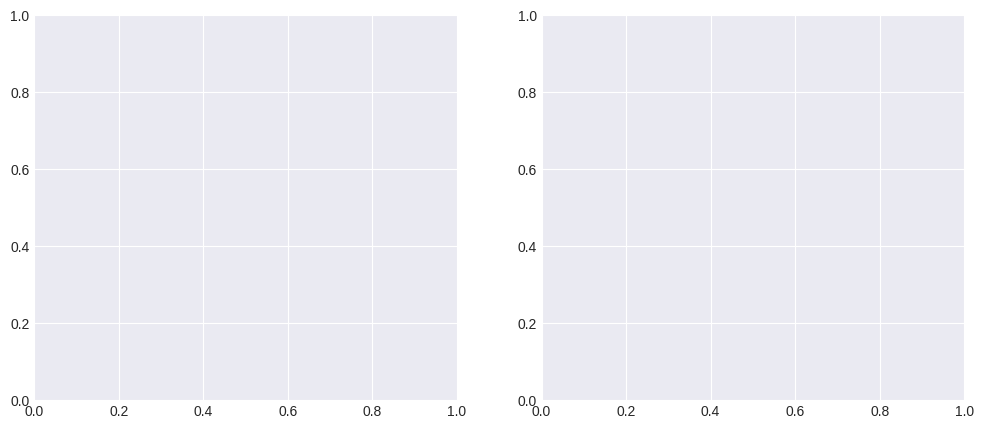

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=analysis_df,
    x='pca1',
    y='pca2',
    hue='error_type',
    style='condition',
    alpha=0.8,
    ax=axes[0],
)
axes[0].set_title('Errors in PCA latent space')

sns.scatterplot(
    data=analysis_df,
    x='umap1',
    y='umap2',
    hue='error_type',
    style='condition',
    alpha=0.8,
    ax=axes[1],
)
axes[1].set_title('Errors in UMAP latent space')

plt.tight_layout()
plt.show()

In [ ]:
cluster_error_df = (
    analysis_df.groupby(['cluster', 'error_type'])
    .size()
    .reset_index(name='n_windows')
)

display(cluster_error_df.sort_values(['cluster', 'error_type']))

In [ ]:
cluster_totals = analysis_df.groupby('cluster').size().rename('total').reset_index()
cluster_errors = (
    analysis_df[analysis_df['correct'] == 0]
    .groupby('cluster')
    .size()
    .rename('n_errors')
    .reset_index()
)

cluster_stats = cluster_totals.merge(cluster_errors, on='cluster', how='left')
cluster_stats['n_errors'] = cluster_stats['n_errors'].fillna(0).astype(int)
cluster_stats['error_rate'] = cluster_stats['n_errors'] / cluster_stats['total']

display(cluster_stats.sort_values('error_rate', ascending=False))

In [ ]:
high_conf_errors = (
    analysis_df[analysis_df['correct'] == 0]
    .sort_values('confidence', ascending=False)
    .reset_index(drop=True)
)

display(high_conf_errors.head(20))

In [ ]:
low_conf_correct = (
    analysis_df[analysis_df['correct'] == 1]
    .sort_values('confidence', ascending=True)
    .reset_index(drop=True)
)

display(low_conf_correct.head(20))

In [ ]:
display(
    analysis_df.groupby(['condition', 'error_type'])['confidence']
    .agg(['count', 'mean', 'std', 'min', 'max'])
    .reset_index()
)

In [ ]:
best_model_name = str(best_baseline_test['model'])
best_model = baseline_models[best_model_name]

test_baseline_proba = best_model.predict_proba(X_test_scaled)[:, 1]
test_baseline_pred = best_model.predict(X_test_scaled)

baseline_test_df = meta_df[meta_df['idx'].isin(test_idx)].copy().sort_values('idx').reset_index(drop=True)
baseline_test_df['baseline_model'] = best_model_name
baseline_test_df['baseline_y_pred'] = test_baseline_pred
baseline_test_df['baseline_y_score'] = test_baseline_proba

compare_pred_df = analysis_df.merge(
    baseline_test_df[['idx', 'baseline_model', 'baseline_y_pred', 'baseline_y_score']],
    on='idx',
    how='left'
)

compare_pred_df['agreement'] = (
    compare_pred_df['y_pred'] == compare_pred_df['baseline_y_pred']
).astype(int)

compare_pred_df['both_wrong'] = (
    (compare_pred_df['y_pred'] != compare_pred_df['y_true']) &
    (compare_pred_df['baseline_y_pred'] != compare_pred_df['y_true'])
).astype(int)

compare_pred_df['stgnn_only_correct'] = (
    (compare_pred_df['y_pred'] == compare_pred_df['y_true']) &
    (compare_pred_df['baseline_y_pred'] != compare_pred_df['y_true'])
).astype(int)

compare_pred_df['baseline_only_correct'] = (
    (compare_pred_df['y_pred'] != compare_pred_df['y_true']) &
    (compare_pred_df['baseline_y_pred'] == compare_pred_df['y_true'])
).astype(int)

display(compare_pred_df.head())

In [ ]:
comparison_summary = {
    'agreement_rate': float(compare_pred_df['agreement'].mean()),
    'both_wrong': int(compare_pred_df['both_wrong'].sum()),
    'stgnn_only_correct': int(compare_pred_df['stgnn_only_correct'].sum()),
    'baseline_only_correct': int(compare_pred_df['baseline_only_correct'].sum()),
}

print(comparison_summary)

In [ ]:
manuscript_error_table = analysis_df[
    ['idx', 'condition', 'frame_time', 'y_true', 'y_pred', 'y_score',
     'confidence', 'error_type', 'cluster', 'pca1', 'pca2', 'umap1', 'umap2']
].copy()

manuscript_cluster_table = cluster_stats.copy()

manuscript_compare_table = compare_pred_df[
    ['idx', 'condition', 'frame_time', 'y_true',
     'y_pred', 'y_score',
     'baseline_model', 'baseline_y_pred', 'baseline_y_score',
     'agreement', 'both_wrong', 'stgnn_only_correct', 'baseline_only_correct']
].copy()

display(manuscript_error_table.head())
display(manuscript_cluster_table.head())
display(manuscript_compare_table.head())

In [ ]:
analysis_df_path = OUTPUT_DIR / 'stgnn_error_analysis.csv'
cluster_stats_path = OUTPUT_DIR / 'stgnn_cluster_error_stats.csv'
high_conf_errors_path = OUTPUT_DIR / 'stgnn_high_conf_errors.csv'
low_conf_correct_path = OUTPUT_DIR / 'stgnn_low_conf_correct.csv'
compare_pred_path = OUTPUT_DIR / 'stgnn_vs_baseline_predictions.csv'
comparison_summary_path = OUTPUT_DIR / 'stgnn_vs_baseline_summary.json'

manuscript_error_table_path = OUTPUT_DIR / 'manuscript_error_table.csv'
manuscript_cluster_table_path = OUTPUT_DIR / 'manuscript_cluster_table.csv'
manuscript_compare_table_path = OUTPUT_DIR / 'manuscript_compare_table.csv'

analysis_df.to_csv(analysis_df_path, index=False)
cluster_stats.to_csv(cluster_stats_path, index=False)
high_conf_errors.to_csv(high_conf_errors_path, index=False)
low_conf_correct.to_csv(low_conf_correct_path, index=False)
compare_pred_df.to_csv(compare_pred_path, index=False)

manuscript_error_table.to_csv(manuscript_error_table_path, index=False)
manuscript_cluster_table.to_csv(manuscript_cluster_table_path, index=False)
manuscript_compare_table.to_csv(manuscript_compare_table_path, index=False)

with open(comparison_summary_path, 'w') as f:
    json.dump(comparison_summary, f, indent=2)

print('Saved:')
print(' -', analysis_df_path)
print(' -', cluster_stats_path)
print(' -', high_conf_errors_path)
print(' -', low_conf_correct_path)
print(' -', compare_pred_path)
print(' -', comparison_summary_path)
print(' -', manuscript_error_table_path)
print(' -', manuscript_cluster_table_path)
print(' -', manuscript_compare_table_path)

## Раздел 9. Reproducibility и финальный экспорт

Этот раздел завершает ноутбук и собирает воспроизводимые артефакты эксперимента:

- конфигурацию запуска;
- версии библиотек и среды;
- ключевые входные файлы;
- итоговые метрики AE, latent-space baselines и ST-GNN;
- сводные таблицы для manuscript/dissertation;
- финальный JSON summary.

Цель — сделать pilot 2.0 воспроизводимым и пригодным для повторного запуска,
сравнения и последующего переноса в MANIA/WANIA pipeline.

In [ ]:
import sys
import platform
import sklearn
import torch
import torch_geometric
import numpy as np
import pandas as pd

env_info = {
    'python_version': sys.version,
    'platform': platform.platform(),
    'numpy_version': np.__version__,
    'pandas_version': pd.__version__,
    'sklearn_version': sklearn.__version__,
    'torch_version': torch.__version__,
    'torch_geometric_version': torch_geometric.__version__,
    'device': str(device),
}
env_info

In [ ]:
input_files_summary = []

for cond in CONFIG['conditions']:
    for key, path in FILE_MAP[cond].items():
        input_files_summary.append({
            'condition': cond,
            'artefact_key': key,
            'path': str(path),
            'exists': Path(path).exists(),
        })

for key, path in FILE_MAP['shared'].items():
    input_files_summary.append({
        'condition': 'shared',
        'artefact_key': key,
        'path': str(path) if path is not None else None,
        'exists': Path(path).exists() if path is not None else False,
    })

input_files_df = pd.DataFrame(input_files_summary)
display(input_files_df)

In [ ]:
data_summary = {
    'n_trajectories': int(len(trajectories)),
    'n_train': int(len(train_ds)),
    'n_val': int(len(val_ds)),
    'n_test': int(len(test_ds)),
    'traj_window': int(CONFIG['traj_window']),
    'traj_stride': int(CONFIG['traj_stride']),
    'n_conditions': int(len(CONFIG['conditions'])),
    'conditions': list(CONFIG['conditions']),
    'label_mapping': CONFIG['condition_to_label'],
    'protein_feat_dim': int(CONFIG['protein_feat_dim']),
    'lipid_feat_dim': int(CONFIG['lipid_feat_dim']) if CONFIG['lipid_feat_dim'] is not None else None,
    'glycan_feat_dim': int(CONFIG['glycan_feat_dim']) if CONFIG['glycan_feat_dim'] is not None else None,
}
data_summary

NameError: name 'trajectories' is not defined

In [ ]:
best_baseline_test = (
    baseline_results_df[baseline_results_df['split'] == 'test']
    .sort_values('roc_auc', ascending=False)
    .iloc[0]
)

final_metrics_df = pd.DataFrame([
    {
        'model': 'Autoencoder',
        'split': 'test',
        'metric_group': 'reconstruction',
        'loss': float(test_metrics_ae['loss']),
        'roc_auc': np.nan,
        'f1': np.nan,
        'mcc': np.nan,
        'accuracy': np.nan,
    },
    {
        'model': str(best_baseline_test['model']),
        'split': 'test',
        'metric_group': 'latent_baseline',
        'loss': np.nan,
        'roc_auc': float(best_baseline_test['roc_auc']),
        'f1': float(best_baseline_test['f1']),
        'mcc': float(best_baseline_test['mcc']),
        'accuracy': float(best_baseline_test['accuracy']),
    },
    {
        'model': 'ST-GNN',
        'split': 'test',
        'metric_group': 'supervised_graph_temporal',
        'loss': float(test_metrics_st['loss']),
        'roc_auc': float(test_metrics_st['roc_auc']),
        'f1': float(test_metrics_st['f1']),
        'mcc': float(test_metrics_st['mcc']),
        'accuracy': float(test_metrics_st['accuracy']),
    },
])

display(final_metrics_df)

In [ ]:
delta_summary = {
    'best_baseline_model': str(best_baseline_test['model']),
    'delta_roc_auc_stgnn_minus_baseline': float(test_metrics_st['roc_auc'] - best_baseline_test['roc_auc']),
    'delta_f1_stgnn_minus_baseline': float(test_metrics_st['f1'] - best_baseline_test['f1']),
    'delta_mcc_stgnn_minus_baseline': float(test_metrics_st['mcc'] - best_baseline_test['mcc']),
    'delta_accuracy_stgnn_minus_baseline': float(test_metrics_st['accuracy'] - best_baseline_test['accuracy']),
}
delta_summary

In [ ]:
cluster_error_summary = {
    'n_unique_clusters': int(latent_all['cluster'].nunique()),
    'n_noise_windows': int((latent_all['cluster'] == -1).sum()) if 'cluster' in latent_all.columns else None,
    'n_test_errors': int((analysis_df['correct'] == 0).sum()),
    'n_test_correct': int((analysis_df['correct'] == 1).sum()),
    'stgnn_only_correct': int(compare_pred_df['stgnn_only_correct'].sum()),
    'baseline_only_correct': int(compare_pred_df['baseline_only_correct'].sum()),
}
cluster_error_summary

In [ ]:
experiment_summary = {
    'project': 'NaPi2b pilot 2.0 ST-GNN',
    'timestamp': pd.Timestamp.now().isoformat(),
    'source_artefacts': SOURCE_ARTEFACTS,
    'yadisk_preprocess_root': YADISK_PREPROCESS_ROOT if SOURCE_ARTEFACTS == 'yadisk' else None,
    'yadisk_analysis_root': YADISK_ANALYSIS_ROOT if SOURCE_ARTEFACTS == 'yadisk' else None,
    'env_info': env_info,
    'config': CONFIG,
    'data_summary': data_summary,
    'final_metrics': final_metrics_df.to_dict(orient='records'),
    'delta_summary': delta_summary,
    'cluster_error_summary': cluster_error_summary,
    'input_files': input_files_df.to_dict(orient='records'),
}

experiment_summary_path = OUTPUT_DIR / 'experiment_summary_pilot2.json'
with open(experiment_summary_path, 'w') as f:
    json.dump(experiment_summary, f, indent=2, default=str)

print('Saved:', experiment_summary_path)

In [ ]:
produced_artefacts = [
    'split_index.json',
    'autoencoder_pilot2.pt',
    'autoencoder_history.csv',
    'latent_embeddings_all.csv',
    'metrics_autoencoder.json',
    'latent_umap.csv',
    'latent_clusters.csv',
    'metrics_baseline.csv',
    'metrics_baseline_best.json',
    'stgnn_pilot2.pt',
    'stgnn_history.csv',
    'metrics_stgnn.json',
    'stgnn_test_predictions.csv',
    'comparison_stgnn_vs_baseline.csv',
    'stgnn_error_analysis.csv',
    'stgnn_cluster_error_stats.csv',
    'stgnn_high_conf_errors.csv',
    'stgnn_low_conf_correct.csv',
    'stgnn_vs_baseline_predictions.csv',
    'stgnn_vs_baseline_summary.json',
    'manuscript_error_table.csv',
    'manuscript_cluster_table.csv',
    'manuscript_compare_table.csv',
    'experiment_summary_pilot2.json',
]

produced_artefacts_df = pd.DataFrame({
    'file_name': produced_artefacts,
    'path': [str(OUTPUT_DIR / f) for f in produced_artefacts],
    'exists': [(OUTPUT_DIR / f).exists() for f in produced_artefacts],
})

display(produced_artefacts_df)

In [ ]:
manuscript_summary = pd.DataFrame([
    {
        'project': 'NaPi2b pilot 2.0',
        'n_windows_total': len(trajectories),
        'traj_window': CONFIG['traj_window'],
        'traj_stride': CONFIG['traj_stride'],
        'best_baseline_model': str(best_baseline_test['model']),
        'best_baseline_roc_auc': float(best_baseline_test['roc_auc']),
        'stgnn_roc_auc': float(test_metrics_st['roc_auc']),
        'stgnn_f1': float(test_metrics_st['f1']),
        'stgnn_mcc': float(test_metrics_st['mcc']),
        'delta_roc_auc': float(delta_summary['delta_roc_auc_stgnn_minus_baseline']),
        'stgnn_only_correct': int(compare_pred_df['stgnn_only_correct'].sum()),
        'baseline_only_correct': int(compare_pred_df['baseline_only_correct'].sum()),
        'n_test_errors': int((analysis_df['correct'] == 0).sum()),
    }
])

display(manuscript_summary)

In [ ]:
input_files_path = OUTPUT_DIR / 'input_files_summary.csv'
final_metrics_path = OUTPUT_DIR / 'final_metrics_summary.csv'
manuscript_summary_path = OUTPUT_DIR / 'manuscript_summary.csv'
env_info_path = OUTPUT_DIR / 'environment_info.json'
data_summary_path = OUTPUT_DIR / 'data_summary.json'
delta_summary_path = OUTPUT_DIR / 'delta_summary.json'
cluster_error_summary_path = OUTPUT_DIR / 'cluster_error_summary.json'

input_files_df.to_csv(input_files_path, index=False)
final_metrics_df.to_csv(final_metrics_path, index=False)
manuscript_summary.to_csv(manuscript_summary_path, index=False)

with open(env_info_path, 'w') as f:
    json.dump(env_info, f, indent=2, default=str)

with open(data_summary_path, 'w') as f:
    json.dump(data_summary, f, indent=2, default=str)

with open(delta_summary_path, 'w') as f:
    json.dump(delta_summary, f, indent=2, default=str)

with open(cluster_error_summary_path, 'w') as f:
    json.dump(cluster_error_summary, f, indent=2, default=str)

print('Saved:')
print(' -', input_files_path)
print(' -', final_metrics_path)
print(' -', manuscript_summary_path)
print(' -', env_info_path)
print(' -', data_summary_path)
print(' -', delta_summary_path)
print(' -', cluster_error_summary_path)

In [ ]:
print('=== FINAL CHECK ===')
print('Input files available:', int(input_files_df['exists'].sum()), '/', len(input_files_df))
print('Produced artefacts available:', int(produced_artefacts_df['exists'].sum()), '/', len(produced_artefacts_df))
print('Best baseline model:', best_baseline_test['model'])
print('Best baseline ROC-AUC:', float(best_baseline_test['roc_auc']))
print('ST-GNN ROC-AUC:', float(test_metrics_st['roc_auc']))
print('Delta ROC-AUC:', float(delta_summary['delta_roc_auc_stgnn_minus_baseline']))
print('Experiment summary:', experiment_summary_path)

## Раздел 10. Интерпретация, выводы и следующие шаги

Этот раздел завершает pilot 2.0 и переводит результаты в исследовательские выводы.

Задачи:
- кратко интерпретировать, что показали AE, latent-space baselines и ST-GNN;
- зафиксировать ограничения текущего пилота;
- сформировать список следующих шагов для production-версии эксперимента;
- подготовить текстовую основу для manuscript/dissertation discussion.

Важно:
- это не «автоматическое доказательство биологии», а аккуратная интерпретация сигналов модели;
- если ST-GNN не превосходит baseline, это тоже валидный результат;
- pilot 2.0 оценивается прежде всего как methodological feasibility study.

In [ ]:
best_baseline_name = str(best_baseline_test['model'])
best_baseline_auc = float(best_baseline_test['roc_auc'])
best_baseline_f1 = float(best_baseline_test['f1'])
best_baseline_mcc = float(best_baseline_test['mcc'])

st_auc = float(test_metrics_st['roc_auc'])
st_f1 = float(test_metrics_st['f1'])
st_mcc = float(test_metrics_st['mcc'])

delta_auc = float(delta_summary['delta_roc_auc_stgnn_minus_baseline'])
delta_f1 = float(delta_summary['delta_f1_stgnn_minus_baseline'])
delta_mcc = float(delta_summary['delta_mcc_stgnn_minus_baseline'])

n_errors = int((analysis_df['correct'] == 0).sum())
n_test = int(len(analysis_df))

interpretation_flags = {
    'ae_has_signal': bool(latent_all[latent_cols].std().mean() > 1e-6),
    'umap_has_clusters': bool(latent_all['cluster'].nunique() > 1) if 'cluster' in latent_all.columns else False,
    'stgnn_beats_baseline_auc': bool(delta_auc > 0),
    'stgnn_beats_baseline_mcc': bool(delta_mcc > 0),
    'error_rate_below_25pct': bool((n_errors / max(n_test, 1)) < 0.25),
}
interpretation_flags

In [ ]:
interpretation_lines = []

interpretation_lines.append(
    f"Autoencoder сформировал невырожденное latent-space представление "
    f"(test reconstruction loss = {float(test_metrics_ae['loss']):.4f})."
)

interpretation_lines.append(
    f"Лучший baseline в latent space: {best_baseline_name} "
    f"(ROC-AUC = {best_baseline_auc:.4f}, F1 = {best_baseline_f1:.4f}, MCC = {best_baseline_mcc:.4f})."
)

interpretation_lines.append(
    f"ST-GNN на test set показал ROC-AUC = {st_auc:.4f}, "
    f"F1 = {st_f1:.4f}, MCC = {st_mcc:.4f}."
)

if delta_auc > 0:
    interpretation_lines.append(
        f"По ROC-AUC ST-GNN превосходит лучший latent-space baseline на {delta_auc:.4f}, "
        f"что поддерживает гипотезу о полезности явного моделирования графовой динамики."
    )
else:
    interpretation_lines.append(
        f"По ROC-AUC ST-GNN не превосходит лучший latent-space baseline "
        f"(delta = {delta_auc:.4f}), что указывает, что основная дискриминационная информация "
        f"уже может быть хорошо закодирована в compact latent representation."
    )

if interpretation_flags['umap_has_clusters']:
    interpretation_lines.append(
        "В latent space наблюдается кластерная структура, что согласуется с наличием "
        "различимых конформационных режимов."
    )
else:
    interpretation_lines.append(
        "Явная кластерная структура в latent space выражена слабо; возможна более непрерывная, "
        "чем дискретная, конформационная динамика."
    )

interpretation_lines.append(
    f"На test set ошибочно классифицировано {n_errors} из {n_test} окон."
)

for line in interpretation_lines:
    print('-', line)

In [ ]:
limitations = [
    'pilot 2.0 основан на ограниченном объёме MD-данных и коротких временных окнах',
    'temporal split выполнен внутри имеющихся траекторий; при нескольких репликах нужен replica-aware split',
    'автоэнкодер реконструирует frame-level embeddings, а не исходную структуру графа',
    'используется SAGE-based hetero-GNN baseline без attention/mechanistic attribution',
    'результаты чувствительны к качеству экспорта MANIA и соглашениям по edge semantics',
    'биологическая интерпретация требует последующей привязки к residue-level / region-level сигналам',
]

limitations_df = pd.DataFrame({'limitation': limitations})
display(limitations_df)

In [ ]:
next_steps = pd.DataFrame([
    {
        'priority': 'high',
        'track': 'data',
        'next_step': 'Добавить дополнительные реплики и replica-aware split',
        'rationale': 'Исключить leakage и повысить статистическую надёжность',
    },
    {
        'priority': 'high',
        'track': 'model',
        'next_step': 'Сравнить SAGEConv с RGAT/GAT вариантом',
        'rationale': 'Проверить, даёт ли edge-type-aware attention выигрыш и интерпретируемость',
    },
    {
        'priority': 'high',
        'track': 'biology',
        'next_step': 'Связать ошибки и confident windows с доменами, эпитопами и ключевыми остатками',
        'rationale': 'Перевести ML-сигнал в биологически интерпретируемые выводы',
    },
    {
        'priority': 'medium',
        'track': 'features',
        'next_step': 'Добавить trajectory-derived residue features (например RMSF, SASA dynamics, contact persistence)',
        'rationale': 'Усилить связь между динамикой и узловыми представлениями',
    },
    {
        'priority': 'medium',
        'track': 'pipeline',
        'next_step': 'Вынести CONFIG и training loop в standalone scripts вне ноутбука',
        'rationale': 'Сделать прототип воспроизводимым и пригодным для MANIA/WANIA integration',
    },
    {
        'priority': 'medium',
        'track': 'evaluation',
        'next_step': 'Добавить repeated runs / seed stability analysis',
        'rationale': 'Оценить устойчивость метрик и latent clustering',
    },
])
display(next_steps)

In [ ]:
candidate_claims = []

candidate_claims.append(
    'Dynamic heterograph representations derived from MANIA exports are sufficient '
    'to train a spatio-temporal graph model on NaPi2b pilot trajectories.'
)

if delta_auc > 0:
    candidate_claims.append(
        'Explicit spatio-temporal graph modeling improves discrimination between normal and tumor conditions '
        'relative to latent-space baselines in the current pilot setup.'
    )
else:
    candidate_claims.append(
        'In the current pilot setup, latent-space baselines capture most of the discriminative signal, '
        'while explicit ST-GNN modeling does not yet provide a strong additional gain.'
    )

if interpretation_flags['umap_has_clusters']:
    candidate_claims.append(
        'Latent-space structure suggests the presence of partially separable conformational regimes.'
    )
else:
    candidate_claims.append(
        'Latent-space organization appears more continuous than strongly clustered, '
        'suggesting gradual rather than sharply separated conformational changes.'
    )

candidate_claims.append(
    'The pilot establishes technical feasibility for integrating MANIA-derived dynamic RINs '
    'with downstream ST-GNN analysis.'
)

claims_df = pd.DataFrame({'candidate_claim': candidate_claims})
display(claims_df)

In [ ]:
discussion_summary = pd.DataFrame([
    {
        'aspect': 'autoencoder',
        'summary': f"Stable latent representation obtained; test loss = {float(test_metrics_ae['loss']):.4f}",
    },
    {
        'aspect': 'best_baseline',
        'summary': f"{best_baseline_name} achieved ROC-AUC = {best_baseline_auc:.4f}",
    },
    {
        'aspect': 'stgnn',
        'summary': f"ST-GNN achieved ROC-AUC = {st_auc:.4f}, F1 = {st_f1:.4f}, MCC = {st_mcc:.4f}",
    },
    {
        'aspect': 'delta_vs_baseline',
        'summary': f"Delta ROC-AUC = {delta_auc:.4f}, Delta MCC = {delta_mcc:.4f}",
    },
    {
        'aspect': 'error_profile',
        'summary': f"{n_errors} errors out of {n_test} test windows",
    },
    {
        'aspect': 'main_take_home',
        'summary': (
            'Pilot 2.0 demonstrates methodological feasibility of MANIA -> latent/ST-GNN workflow '
            'for NaPi2b dynamic graphs'
        ),
    },
])

display(discussion_summary)

In [ ]:
limitations_path = OUTPUT_DIR / 'discussion_limitations.csv'
next_steps_path = OUTPUT_DIR / 'discussion_next_steps.csv'
claims_path = OUTPUT_DIR / 'discussion_candidate_claims.csv'
discussion_summary_path = OUTPUT_DIR / 'discussion_summary.csv'
interpretation_flags_path = OUTPUT_DIR / 'discussion_interpretation_flags.json'
interpretation_text_path = OUTPUT_DIR / 'discussion_interpretation_text.txt'

limitations_df.to_csv(limitations_path, index=False)
next_steps.to_csv(next_steps_path, index=False)
claims_df.to_csv(claims_path, index=False)
discussion_summary.to_csv(discussion_summary_path, index=False)

with open(interpretation_flags_path, 'w') as f:
    json.dump(interpretation_flags, f, indent=2)

with open(interpretation_text_path, 'w', encoding='utf-8') as f:
    for line in interpretation_lines:
        f.write(line + '\n')

print('Saved:')
print(' -', limitations_path)
print(' -', next_steps_path)
print(' -', claims_path)
print(' -', discussion_summary_path)
print(' -', interpretation_flags_path)
print(' -', interpretation_text_path)

NameError: name 'limitations_df' is not defined

In [ ]:
print('=== EXECUTIVE SUMMARY ===')
for line in interpretation_lines:
    print('-', line)

print('\n=== KEY LIMITATION ===')
print('-', limitations[0])

print('\n=== TOP NEXT STEP ===')
print('-', next_steps.iloc[0]['next_step'])

print('\n=== MAIN TAKE-HOME ===')
print('-', discussion_summary.loc[discussion_summary['aspect'] == 'main_take_home', 'summary'].iloc[0])

## Раздел 11. Экспорт артефактов на Яндекс.Диск

Финальный блок:
- собирает артефакты, созданные в разделах 3–10;
- проверяет, какие файлы реально существуют локально;
- формирует manifest локального экспорта;
- загружает результаты на Яндекс.Диск в воспроизводимую структуру папок;
- сохраняет отчёт об upload и remote manifest.

Важно:
- раздел использует helper-функции из раздела 0b:
  `resolve_ya_disk_token`, `get_yadisk_client`, `yd_exists`, `yd_mkdir_p`, `yadisk_upload_file`;
- upload выполняется только для реально существующих файлов;
- при повторном запуске файлы перезаписываются (`overwrite=True`).

In [ ]:
from pathlib import Path
import hashlib
import json
import mimetypes

YADISK_RESULTS_ROOT = Path('/Apps/ManiaSTGNN/results/pilot2')
YADISK_RESULTS_FIGURES = YADISK_RESULTS_ROOT / 'figures'
YADISK_RESULTS_TABLES = YADISK_RESULTS_ROOT / 'tables'
YADISK_RESULTS_MODELS = YADISK_RESULTS_ROOT / 'models'
YADISK_RESULTS_SUMMARY = YADISK_RESULTS_ROOT / 'summary'

print('YADISK_RESULTS_ROOT =', YADISK_RESULTS_ROOT)

In [ ]:
def file_md5(path: Path, chunk_size: int = 8192):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def infer_artefact_category(path: Path):
    suffix = path.suffix.lower()

    if suffix in ['.png', '.jpg', '.jpeg', '.svg', '.pdf']:
        return 'figures'
    if suffix in ['.pt', '.pth', '.pkl']:
        return 'models'
    if suffix in ['.json', '.txt', '.md']:
        return 'summary'
    return 'tables'


def yadisk_safe_category_path(category: str):
    if category == 'figures':
        return YADISK_RESULTS_FIGURES
    if category == 'models':
        return YADISK_RESULTS_MODELS
    if category == 'summary':
        return YADISK_RESULTS_SUMMARY
    return YADISK_RESULTS_TABLES

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('FIG_DIR =', FIG_DIR)

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_ae_df['epoch'], history_ae_df['train_loss'], label='train_loss')
plt.plot(history_ae_df['epoch'], history_ae_df['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Autoencoder training curves')
plt.legend()
plt.tight_layout()

ae_fig_path = FIG_DIR / 'ae_learning_curves.png'
plt.savefig(ae_fig_path, dpi=300, bbox_inches='tight')
plt.close()

print('Saved:', ae_fig_path)

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=latent_all,
    x='pca1',
    y='pca2',
    hue='condition',
    style='split',
    alpha=0.7,
)
plt.title('Latent PCA by condition')
plt.tight_layout()

pca_fig_path = FIG_DIR / 'latent_pca.png'
plt.savefig(pca_fig_path, dpi=300, bbox_inches='tight')
plt.close()

print('Saved:', pca_fig_path)

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=latent_all,
    x='umap1',
    y='umap2',
    hue='condition',
    style='split',
    alpha=0.7,
)
plt.title('UMAP by condition')
plt.tight_layout()

umap_fig_path = FIG_DIR / 'latent_umap.png'
plt.savefig(umap_fig_path, dpi=300, bbox_inches='tight')
plt.close()

print('Saved:', umap_fig_path)

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_st_df['epoch'], history_st_df['train_loss'], label='train_loss')
plt.plot(history_st_df['epoch'], history_st_df['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('ST-GNN training curves')
plt.legend()
plt.tight_layout()

st_fig_path = FIG_DIR / 'stgnn_learning_curves.png'
plt.savefig(st_fig_path, dpi=300, bbox_inches='tight')
plt.close()

print('Saved:', st_fig_path)

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(test_metrics_st['y_true'], test_metrics_st['y_score'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'ST-GNN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve on test set')
plt.legend()
plt.tight_layout()

roc_fig_path = FIG_DIR / 'stgnn_roc_curve.png'
plt.savefig(roc_fig_path, dpi=300, bbox_inches='tight')
plt.close()

print('Saved:', roc_fig_path)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_metrics_st['y_true'], test_metrics_st['y_pred'])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['normal', 'tumor']
)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion matrix on test set')
plt.tight_layout()

cm_fig_path = FIG_DIR / 'stgnn_confusion_matrix.png'
plt.savefig(cm_fig_path, dpi=300, bbox_inches='tight')
plt.close()

print('Saved:', cm_fig_path)

NameError: name 'test_metrics_st' is not defined

In [ ]:
plt.figure(figsize=(8, 4))
sns.scatterplot(
    data=analysis_df.sort_values('frame_time'),
    x='frame_time',
    y='y_score',
    hue='error_type',
    style='condition',
    alpha=0.8,
)
plt.axhline(0.5, linestyle='--', color='gray')
plt.xlabel('Central frame of window')
plt.ylabel('Predicted probability of tumor')
plt.title('ST-GNN predictions over time')
plt.tight_layout()

err_time_fig_path = FIG_DIR / 'stgnn_error_time.png'
plt.savefig(err_time_fig_path, dpi=300, bbox_inches='tight')
plt.close()

print('Saved:', err_time_fig_path)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=analysis_df,
    x='pca1',
    y='pca2',
    hue='error_type',
    style='condition',
    alpha=0.8,
    ax=axes[0],
)
axes[0].set_title('Errors in PCA space')

sns.scatterplot(
    data=analysis_df,
    x='umap1',
    y='umap2',
    hue='error_type',
    style='condition',
    alpha=0.8,
    ax=axes[1],
)
axes[1].set_title('Errors in UMAP space')

plt.tight_layout()

err_umap_fig_path = FIG_DIR / 'stgnn_error_umap_pca.png'
plt.savefig(err_umap_fig_path, dpi=300, bbox_inches='tight')
plt.close()

print('Saved:', err_umap_fig_path)

In [ ]:
saved_figures = list(FIG_DIR.glob('*.png'))
print('Saved figures:')
for p in saved_figures:
    print(' -', p.name)

NameError: name 'FIG_DIR' is not defined

In [ ]:
artefact_registry = [
    OUTPUT_DIR / 'split_index.json',

    OUTPUT_DIR / 'autoencoder_pilot2.pt',
    OUTPUT_DIR / 'autoencoder_history.csv',
    OUTPUT_DIR / 'latent_embeddings_all.csv',
    OUTPUT_DIR / 'metrics_autoencoder.json',

    OUTPUT_DIR / 'latent_umap.csv',
    OUTPUT_DIR / 'latent_clusters.csv',
    OUTPUT_DIR / 'metrics_baseline.csv',
    OUTPUT_DIR / 'metrics_baseline_best.json',

    OUTPUT_DIR / 'stgnn_pilot2.pt',
    OUTPUT_DIR / 'stgnn_history.csv',
    OUTPUT_DIR / 'metrics_stgnn.json',
    OUTPUT_DIR / 'stgnn_test_predictions.csv',
    OUTPUT_DIR / 'comparison_stgnn_vs_baseline.csv',

    OUTPUT_DIR / 'stgnn_error_analysis.csv',
    OUTPUT_DIR / 'stgnn_cluster_error_stats.csv',
    OUTPUT_DIR / 'stgnn_high_conf_errors.csv',
    OUTPUT_DIR / 'stgnn_low_conf_correct.csv',
    OUTPUT_DIR / 'stgnn_vs_baseline_predictions.csv',
    OUTPUT_DIR / 'stgnn_vs_baseline_summary.json',

    OUTPUT_DIR / 'manuscript_error_table.csv',
    OUTPUT_DIR / 'manuscript_cluster_table.csv',
    OUTPUT_DIR / 'manuscript_compare_table.csv',

    OUTPUT_DIR / 'experiment_summary_pilot2.json',
    OUTPUT_DIR / 'input_files_summary.csv',
    OUTPUT_DIR / 'final_metrics_summary.csv',
    OUTPUT_DIR / 'manuscript_summary.csv',
    OUTPUT_DIR / 'environment_info.json',
    OUTPUT_DIR / 'data_summary.json',
    OUTPUT_DIR / 'delta_summary.json',
    OUTPUT_DIR / 'cluster_error_summary.json',

    OUTPUT_DIR / 'discussion_limitations.csv',
    OUTPUT_DIR / 'discussion_next_steps.csv',
    OUTPUT_DIR / 'discussion_candidate_claims.csv',
    OUTPUT_DIR / 'discussion_summary.csv',
    OUTPUT_DIR / 'discussion_interpretation_flags.json',
    OUTPUT_DIR / 'discussion_interpretation_text.txt',

    OUTPUT_DIR / 'export_manifest_local.json',
    OUTPUT_DIR / 'yadisk_upload_report.csv',
    OUTPUT_DIR / 'export_manifest_yadisk.json',
]

# Если ключевые фигуры были сохранены в OUTPUT_DIR/figures
fig_dir = OUTPUT_DIR / 'figures'
figure_candidates = [
    fig_dir / 'ae_learning_curves.png',
    fig_dir / 'latent_pca.png',
    fig_dir / 'latent_umap.png',
    fig_dir / 'stgnn_learning_curves.png',
    fig_dir / 'stgnn_roc_curve.png',
    fig_dir / 'stgnn_confusion_matrix.png',
    fig_dir / 'stgnn_error_time.png',
    fig_dir / 'stgnn_error_umap_pca.png',
]

artefact_registry.extend(figure_candidates)
artefact_registry = [Path(p) for p in artefact_registry]

print('Expected artefacts:', len(artefact_registry))

In [ ]:
artefact_rows = []

for path in artefact_registry:
    exists = path.exists()
    artefact_rows.append({
        'local_path': str(path),
        'file_name': path.name,
        'exists': exists,
        'size_bytes': path.stat().st_size if exists else None,
        'category': infer_artefact_category(path),
    })

artefact_export_df = pd.DataFrame(artefact_rows)
display(artefact_export_df)

In [ ]:
existing_artefacts_df = artefact_export_df[artefact_export_df['exists']].copy().reset_index(drop=True)
existing_artefacts_df['md5'] = existing_artefacts_df['local_path'].apply(lambda p: file_md5(Path(p)))
existing_artefacts_df['mime_type'] = existing_artefacts_df['local_path'].apply(
    lambda p: mimetypes.guess_type(p)[0] if mimetypes.guess_type(p)[0] is not None else 'application/octet-stream'
)

print('Existing artefacts:', len(existing_artefacts_df))
display(existing_artefacts_df.head())

In [ ]:
local_manifest = {
    'project': 'NaPi2b pilot 2.0 ST-GNN',
    'timestamp': pd.Timestamp.now().isoformat(),
    'local_output_dir': str(OUTPUT_DIR),
    'n_files': int(len(existing_artefacts_df)),
    'files': existing_artefacts_df.to_dict(orient='records'),
}

local_manifest_path = OUTPUT_DIR / 'export_manifest_local.json'
with open(local_manifest_path, 'w') as f:
    json.dump(local_manifest, f, indent=2, default=str)

print('Saved:', local_manifest_path)

NameError: name 'existing_artefacts_df' is not defined

In [ ]:
# Проверка токена/клиента
client = get_yadisk_client()

yd_mkdir_p(str(YADISK_RESULTS_ROOT))
yd_mkdir_p(str(YADISK_RESULTS_FIGURES))
yd_mkdir_p(str(YADISK_RESULTS_TABLES))
yd_mkdir_p(str(YADISK_RESULTS_MODELS))
yd_mkdir_p(str(YADISK_RESULTS_SUMMARY))

print('YaDisk directories are ready.')

In [ ]:
upload_rows = []

for _, row in existing_artefacts_df.iterrows():
    local_path = Path(row['local_path'])
    category = row['category']
    remote_dir = yadisk_safe_category_path(category)
    remote_path = str((remote_dir / local_path.name)).replace('\\', '/')

    try:
        yadisk_upload_file(local_path, remote_path, overwrite=True)
        upload_rows.append({
            'local_path': str(local_path),
            'remote_path': remote_path,
            'category': category,
            'status': 'uploaded',
            'size_bytes': int(local_path.stat().st_size),
        })
        print(f'[uploaded] {local_path.name} -> {remote_path}')
    except Exception as e:
        upload_rows.append({
            'local_path': str(local_path),
            'remote_path': remote_path,
            'category': category,
            'status': f'failed: {type(e).__name__}: {e}',
            'size_bytes': int(local_path.stat().st_size) if local_path.exists() else None,
        })
        print(f'[failed] {local_path.name} -> {remote_path} | {type(e).__name__}: {e}')

In [ ]:
upload_report_df = pd.DataFrame(upload_rows)
display(upload_report_df)

In [ ]:
upload_report_path = OUTPUT_DIR / 'yadisk_upload_report.csv'
upload_report_df.to_csv(upload_report_path, index=False)

remote_manifest = {
    'project': 'NaPi2b pilot 2.0 ST-GNN',
    'timestamp': pd.Timestamp.now().isoformat(),
    'remote_root': str(YADISK_RESULTS_ROOT),
    'n_uploaded': int((upload_report_df['status'] == 'uploaded').sum()),
    'n_failed': int((upload_report_df['status'] != 'uploaded').sum()),
    'files': upload_report_df.to_dict(orient='records'),
}

remote_manifest_path = OUTPUT_DIR / 'export_manifest_yadisk.json'
with open(remote_manifest_path, 'w') as f:
    json.dump(remote_manifest, f, indent=2, default=str)

print('Saved:')
print(' -', upload_report_path)
print(' -', remote_manifest_path)

NameError: name 'upload_report_df' is not defined

In [ ]:
summary_files_to_upload = [
    local_manifest_path,
    upload_report_path,
    remote_manifest_path,
]

summary_upload_rows = []

for local_path in summary_files_to_upload:
    remote_path = str((YADISK_RESULTS_SUMMARY / local_path.name)).replace('\\', '/')
    try:
        yadisk_upload_file(local_path, remote_path, overwrite=True)
        summary_upload_rows.append({
            'local_path': str(local_path),
            'remote_path': remote_path,
            'status': 'uploaded',
        })
        print(f'[uploaded summary] {local_path.name} -> {remote_path}')
    except Exception as e:
        summary_upload_rows.append({
            'local_path': str(local_path),
            'remote_path': remote_path,
            'status': f'failed: {type(e).__name__}: {e}',
        })
        print(f'[failed summary] {local_path.name} -> {remote_path} | {type(e).__name__}: {e}')

summary_upload_df = pd.DataFrame(summary_upload_rows)
display(summary_upload_df)

In [ ]:
n_uploaded = int((upload_report_df['status'] == 'uploaded').sum())
n_failed = int((upload_report_df['status'] != 'uploaded').sum())

print('=== YADISK EXPORT SUMMARY ===')
print('Remote root:', YADISK_RESULTS_ROOT)
print('Existing local artefacts:', len(existing_artefacts_df))
print('Uploaded files:', n_uploaded)
print('Failed files:', n_failed)

print('\nBy category:')
display(
    upload_report_df.groupby(['category', 'status'])
    .size()
    .reset_index(name='n_files')
)

if n_failed > 0:
    print('\nFailed uploads:')
    display(upload_report_df[upload_report_df['status'] != 'uploaded'])

In [ ]:
final_export_summary = {
    'project': 'NaPi2b pilot 2.0 ST-GNN',
    'timestamp': pd.Timestamp.now().isoformat(),
    'local_output_dir': str(OUTPUT_DIR),
    'remote_root': str(YADISK_RESULTS_ROOT),
    'n_existing_local_artefacts': int(len(existing_artefacts_df)),
    'n_uploaded': int((upload_report_df['status'] == 'uploaded').sum()),
    'n_failed': int((upload_report_df['status'] != 'uploaded').sum()),
    'categories': (
        upload_report_df.groupby('category')
        .size()
        .to_dict()
        if len(upload_report_df) > 0 else {}
    ),
}

final_export_summary_path = OUTPUT_DIR / 'final_export_summary.json'
with open(final_export_summary_path, 'w') as f:
    json.dump(final_export_summary, f, indent=2, default=str)

print('Saved:', final_export_summary_path)

NameError: name 'YADISK_RESULTS_ROOT' is not defined

In [ ]:
final_remote_summary_path = str((YADISK_RESULTS_SUMMARY / final_export_summary_path.name)).replace('\\', '/')

try:
    yadisk_upload_file(final_export_summary_path, final_remote_summary_path, overwrite=True)
    print(f'[uploaded summary] {final_export_summary_path.name} -> {final_remote_summary_path}')
except Exception as e:
    print(f'[failed summary] {final_export_summary_path.name} -> {final_remote_summary_path} | {type(e).__name__}: {e}')